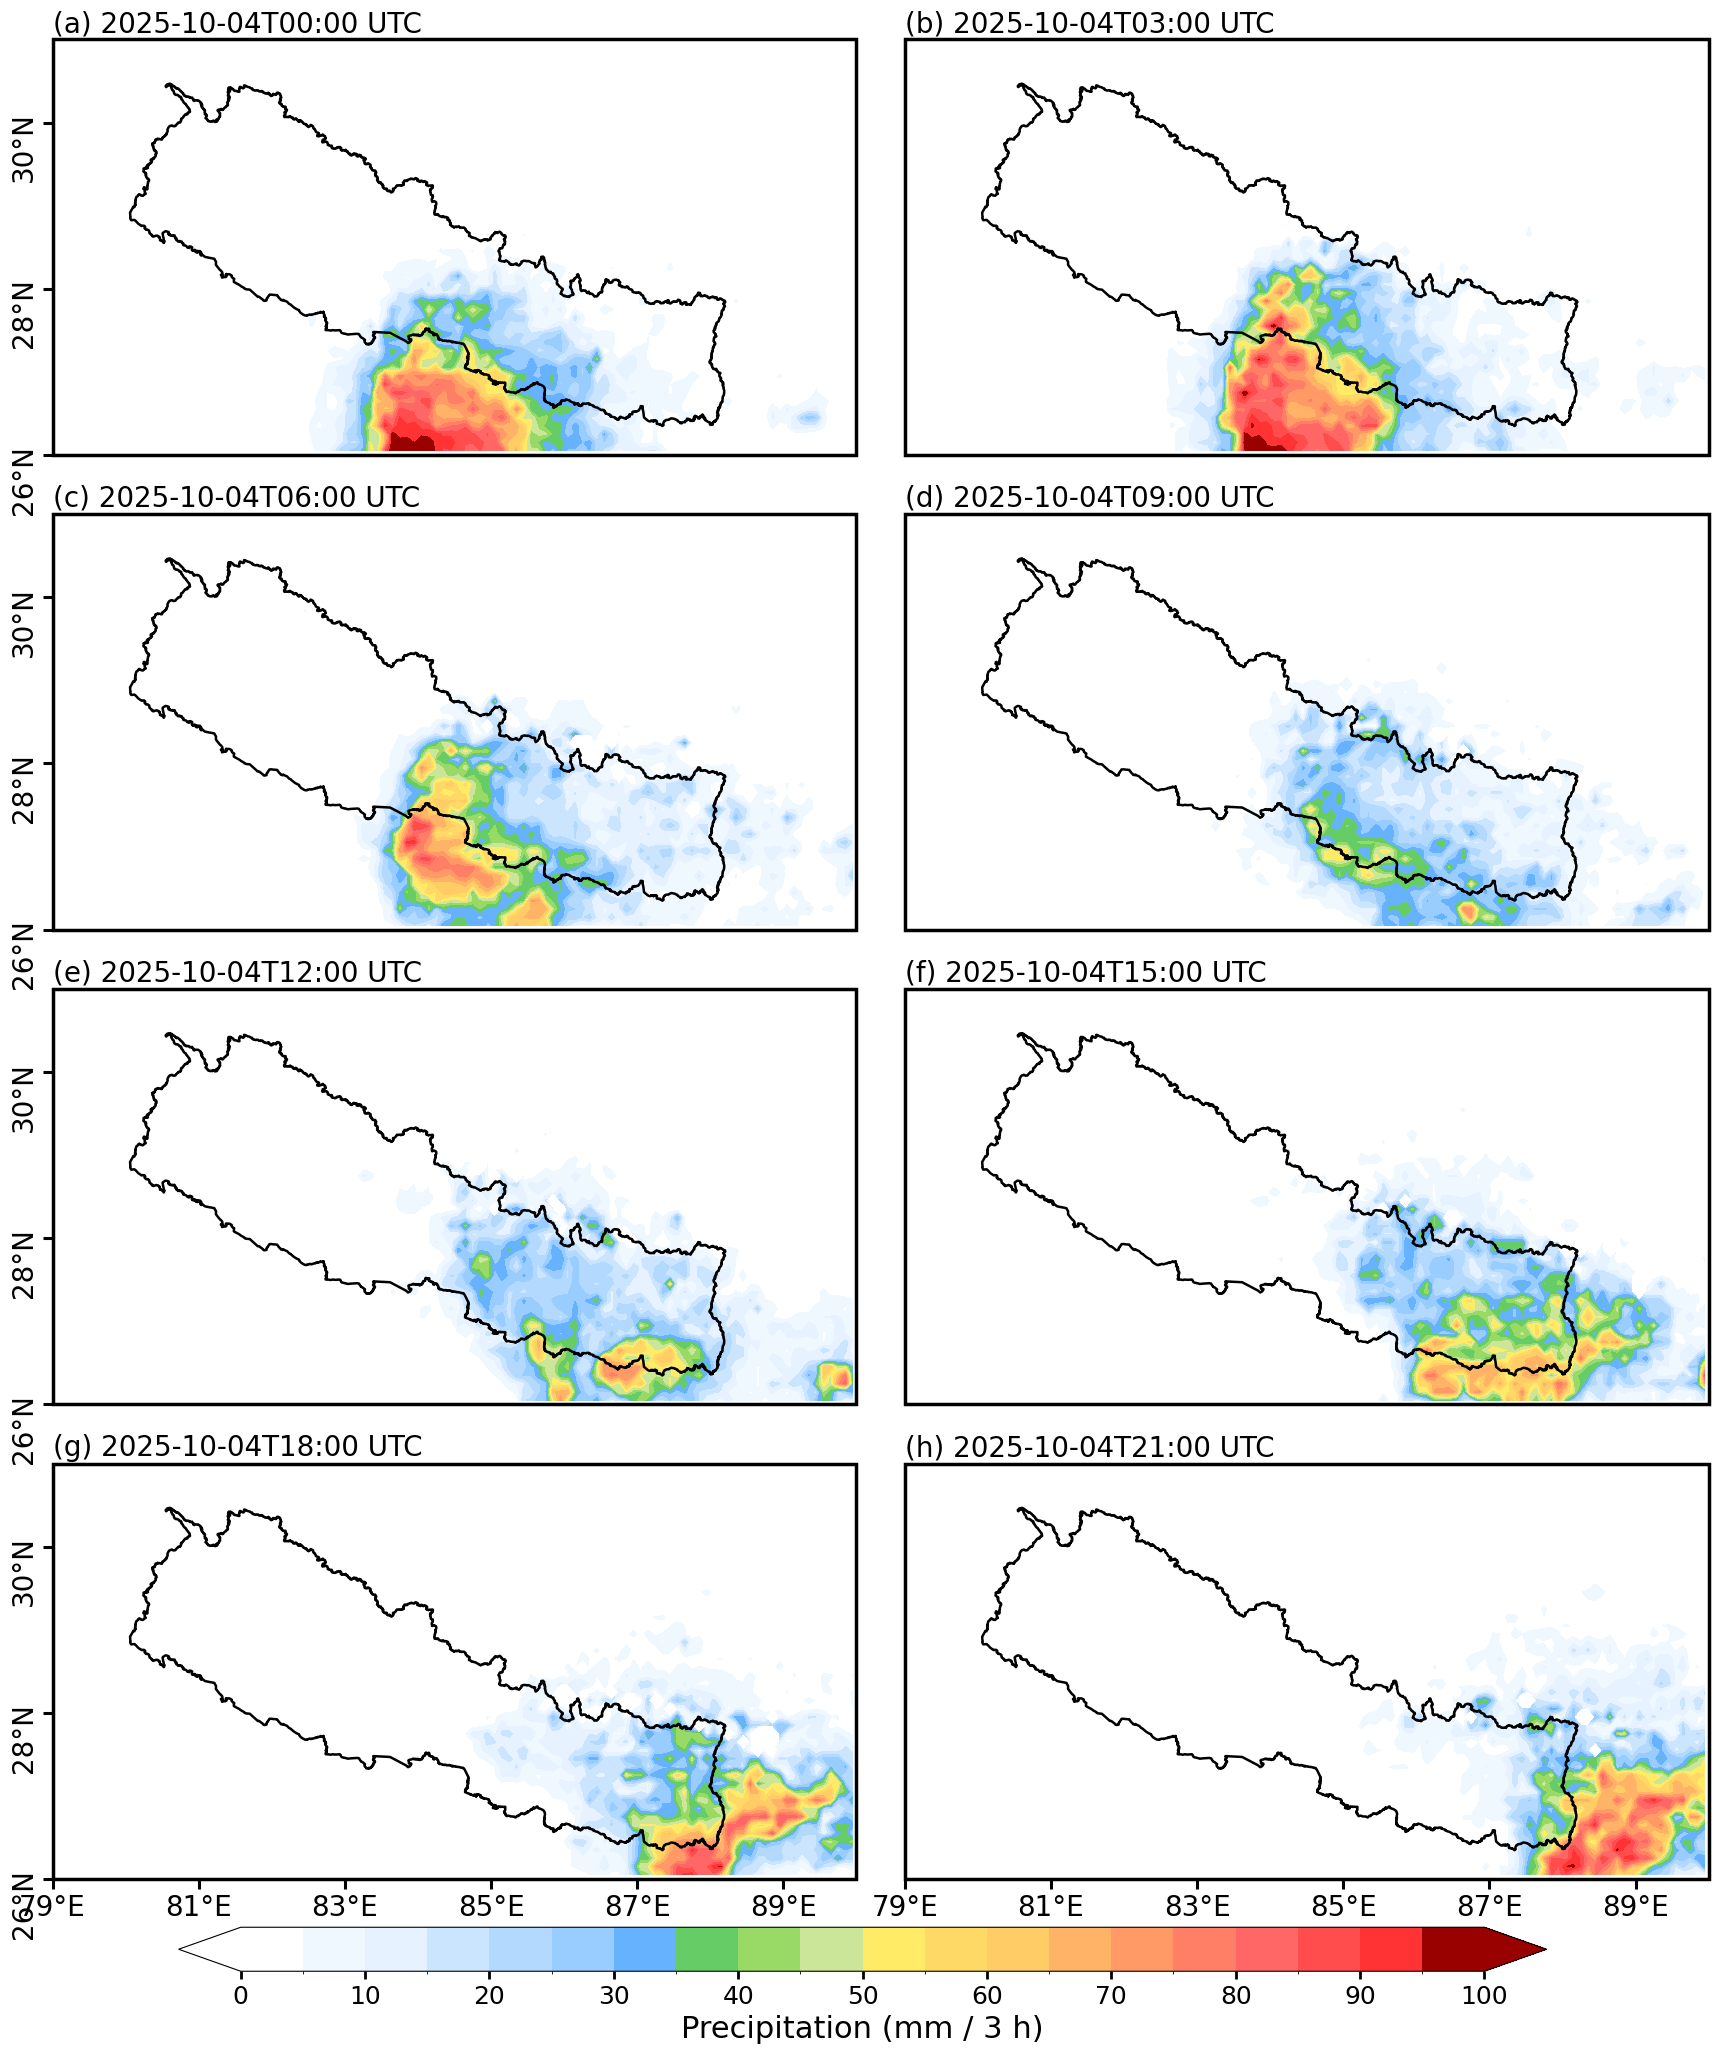

In [2]:

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import glob
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# -------------------------------------------------
# Folder with all NetCDF files
# -------------------------------------------------
nc_folder = '/Users/beekenshrestha/Downloads/RESEARCH/oct4/3h_MSWEP'
nc_files = sorted(glob.glob(os.path.join(nc_folder, '*.nc')))

# -------------------------------------------------
# Load shapefile
# -------------------------------------------------
shp_path = '/Users/beekenshrestha/Downloads/NPL/Nepal_shp/hermes_NPL_new_wgs_0.shp'
shp = gpd.read_file(shp_path)

# -------------------------------------------------
# Colormap
# -------------------------------------------------
bounds = np.array([0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100])

colors = [
    "#ffffff","#f0f8ff","#e6f2ff","#cce5ff","#b3d9ff",
    "#99ccff","#66b2ff","#66cc66","#99d966","#cce699",
    "#ffff66","#ffeb66","#ffd966","#ffcc66","#ffb366",
    "#ff9966","#ff7f66","#ff6666","#ff4d4d","#ff3333",
    "#cc0000","#990000"
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, axes = plt.subplots(
    4, 2, figsize=(18, 22),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# -------------------------------------------------
# Load all time steps
# -------------------------------------------------
da_list, time_list = [], []

for f in nc_files:
    ds = xr.open_dataset(f)
    da = ds['precipitation']
    for t in da.time:
        da_list.append(da.sel(time=t))
        time_list.append(t)

n_panels = min(len(da_list), 8)

panel_labels = list("abcdefgh")

# -------------------------------------------------
# Plot
# -------------------------------------------------
for i in range(n_panels):

    ax = axes[i]
    da2d = da_list[i]

    # Correct lat order
    if da2d.lat[0] > da2d.lat[-1]:
        da2d = da2d.sel(lat=slice(31, 26), lon=slice(79, 90))
    else:
        da2d = da2d.sel(lat=slice(26, 31), lon=slice(79, 90))

    lat = da2d.lat.values
    lon = da2d.lon.values
    lon2d, lat2d = np.meshgrid(lon, lat)

    da_masked = np.ma.masked_equal(da2d, 0)

    cf = ax.contourf(
        lon2d, lat2d, da_masked,
        levels=bounds, cmap=cmap, norm=norm,
        extend='both'
    )

    # ✅ Thicker Nepal boundary
    shp.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.8)

    ax.set_extent([79, 90, 26, 31], crs=ccrs.PlateCarree())

    # Title
    time_str = np.datetime_as_string(da2d['time'].values, unit='m')
    ax.set_title(f"({panel_labels[i]}) {time_str} UTC",
                 fontsize=20, loc='left')

    # -------------------------------------------------
    # TICKS (THICKER)
    # -------------------------------------------------

    if i % 2 == 0:
        ax.set_yticks(np.arange(26, 32, 2), crs=ccrs.PlateCarree())
        ax.yaxis.set_major_formatter(LatitudeFormatter(degree_symbol='°'))

        ax.tick_params(axis='y',
                       labelsize=20,
                       width=2.2,   # ✅ thickness
                       length=7,rotation=90)    # ✅ length
    else:
        ax.set_yticklabels([])

    if i >= 6:
        ax.set_xticks(np.arange(79, 91, 2), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(degree_symbol='°'))

        ax.tick_params(axis='x',
                       labelsize=20,
                       width=2.2,   # ✅ thickness
                       length=7)    # ✅ length
    else:
        ax.set_xticklabels([])

    # ✅ Thicker rectangular border (axes frame)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

# -------------------------------------------------
# Hide unused axes
# -------------------------------------------------
for j in range(n_panels, 8):
    axes[j].axis('off')

# -------------------------------------------------
# Colorbar
# -------------------------------------------------
cbar_ax = fig.add_axes([0.12, 0.08, 0.76, 0.02])
cbar = fig.colorbar(
    cf, cax=cbar_ax,
    orientation='horizontal',
    ticks=bounds[::2]
)

cbar.set_label('Precipitation (mm / 3 h)', fontsize=22)

# ✅ Thicker colorbar ticks
cbar.ax.tick_params(labelsize=18, width=2, length=6)

# -------------------------------------------------
# Layout
# -------------------------------------------------
plt.subplots_adjust(
    left=0.05, right=0.97,
    top=0.96, bottom=0.12,
    wspace=0.06, hspace=0.12
)

plt.savefig(
    "/Users/beekenshrestha/Downloads/RESEARCH/oct4/output/3h.png",
    dpi=450, bbox_inches='tight'
)

plt.show()


In [5]:

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import glob
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# -------------------------------------------------
# Folder with all NetCDF files
# -------------------------------------------------
nc_folder = '/Users/beekenshrestha/Downloads/RESEARCH/oct4/3h_MSWEP'
nc_files = sorted(glob.glob(os.path.join(nc_folder, '*.nc')))

# -------------------------------------------------
# Load shapefile
# -------------------------------------------------
shp_path = '/Users/beekenshrestha/Downloads/NPL/Nepal_shp/hermes_NPL_new_wgs_0.shp'
shp = gpd.read_file(shp_path)

# -------------------------------------------------
# Colormap
# -------------------------------------------------
bounds = np.array([0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100])

colors = [
    "#ffffff","#f0f8ff","#e6f2ff","#cce5ff","#b3d9ff",
    "#99ccff","#66b2ff","#66cc66","#99d966","#cce699",
    "#ffff66","#ffeb66","#ffd966","#ffcc66","#ffb366",
    "#ff9966","#ff7f66","#ff6666","#ff4d4d","#ff3333",
    "#cc0000","#990000"
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, axes = plt.subplots(
    4, 2, figsize=(18, 22),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# -------------------------------------------------
# Load all time steps
# -------------------------------------------------
da_list, time_list = [], []

for f in nc_files:
    ds = xr.open_dataset(f)
    da = ds['precipitation']
    for t in da.time:
        da_list.append(da.sel(time=t))
        time_list.append(t)

n_panels = min(len(da_list), 8)

# panel labels
panel_labels = list("abcdefgh")

# -------------------------------------------------
# Plot
# -------------------------------------------------
for i in range(n_panels):

    ax = axes[i]
    da2d = da_list[i]

    # Correct lat order
    if da2d.lat[0] > da2d.lat[-1]:
        da2d = da2d.sel(lat=slice(31, 26), lon=slice(79, 90))
    else:
        da2d = da2d.sel(lat=slice(26, 31), lon=slice(79, 90))

    lat = da2d.lat.values
    lon = da2d.lon.values
    lon2d, lat2d = np.meshgrid(lon, lat)

    da_masked = np.ma.masked_equal(da2d, 0)

    cf = ax.contourf(
        lon2d, lat2d, da_masked,
        levels=bounds, cmap=cmap, norm=norm,
        extend='both'
    )

    # Nepal boundary
    shp.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

    ax.set_extent([79, 90, 26, 31], crs=ccrs.PlateCarree())

    # ---- Panel label + time (LEFT aligned) ----
    time_str = np.datetime_as_string(da2d['time'].values, unit='m')
    ax.set_title(f"({panel_labels[i]}) {time_str} UTC",
                 fontsize=20, loc='left')

    # ---- TICKS ----

    # Y ticks (left column only)
    if i % 2 == 0:
        ax.set_yticks(np.arange(26, 32, 2), crs=ccrs.PlateCarree())
        ax.yaxis.set_major_formatter(LatitudeFormatter(degree_symbol='°'))
        ax.tick_params(axis='y', labelsize=16)
    else:
        ax.set_yticklabels([])

    # X ticks (bottom row only)
    if i >= 6:
        ax.set_xticks(np.arange(79, 91, 2), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(degree_symbol='°'))
        ax.tick_params(axis='x', labelsize=16)
    else:
        ax.set_xticklabels([])
       

# -------------------------------------------------
# Hide unused axes
# -------------------------------------------------
for j in range(n_panels, 8):
    axes[j].axis('off')


# -------------------------------------------------
# Colorbar
# -------------------------------------------------
cbar_ax = fig.add_axes([0.12, 0.08, 0.76, 0.02])
cbar = fig.colorbar(
    cf, cax=cbar_ax,
    orientation='horizontal',
    ticks=bounds[::2]
)

cbar.set_label('Precipitation (mm / 3 h)', fontsize=22)
cbar.ax.tick_params(labelsize=18)

# -------------------------------------------------
# Layout
# -------------------------------------------------
plt.subplots_adjust(
    left=0.05, right=0.97,
    top=0.96, bottom=0.12,
    wspace=0.06, hspace=0.12
)

plt.savefig("/Users/beekenshrestha/Downloads/RESEARCH/oct4/output/3h.png", dpi=1050, bbox_inches='tight')
plt.show()


IndentationError: unexpected indent (1147951216.py, line 127)

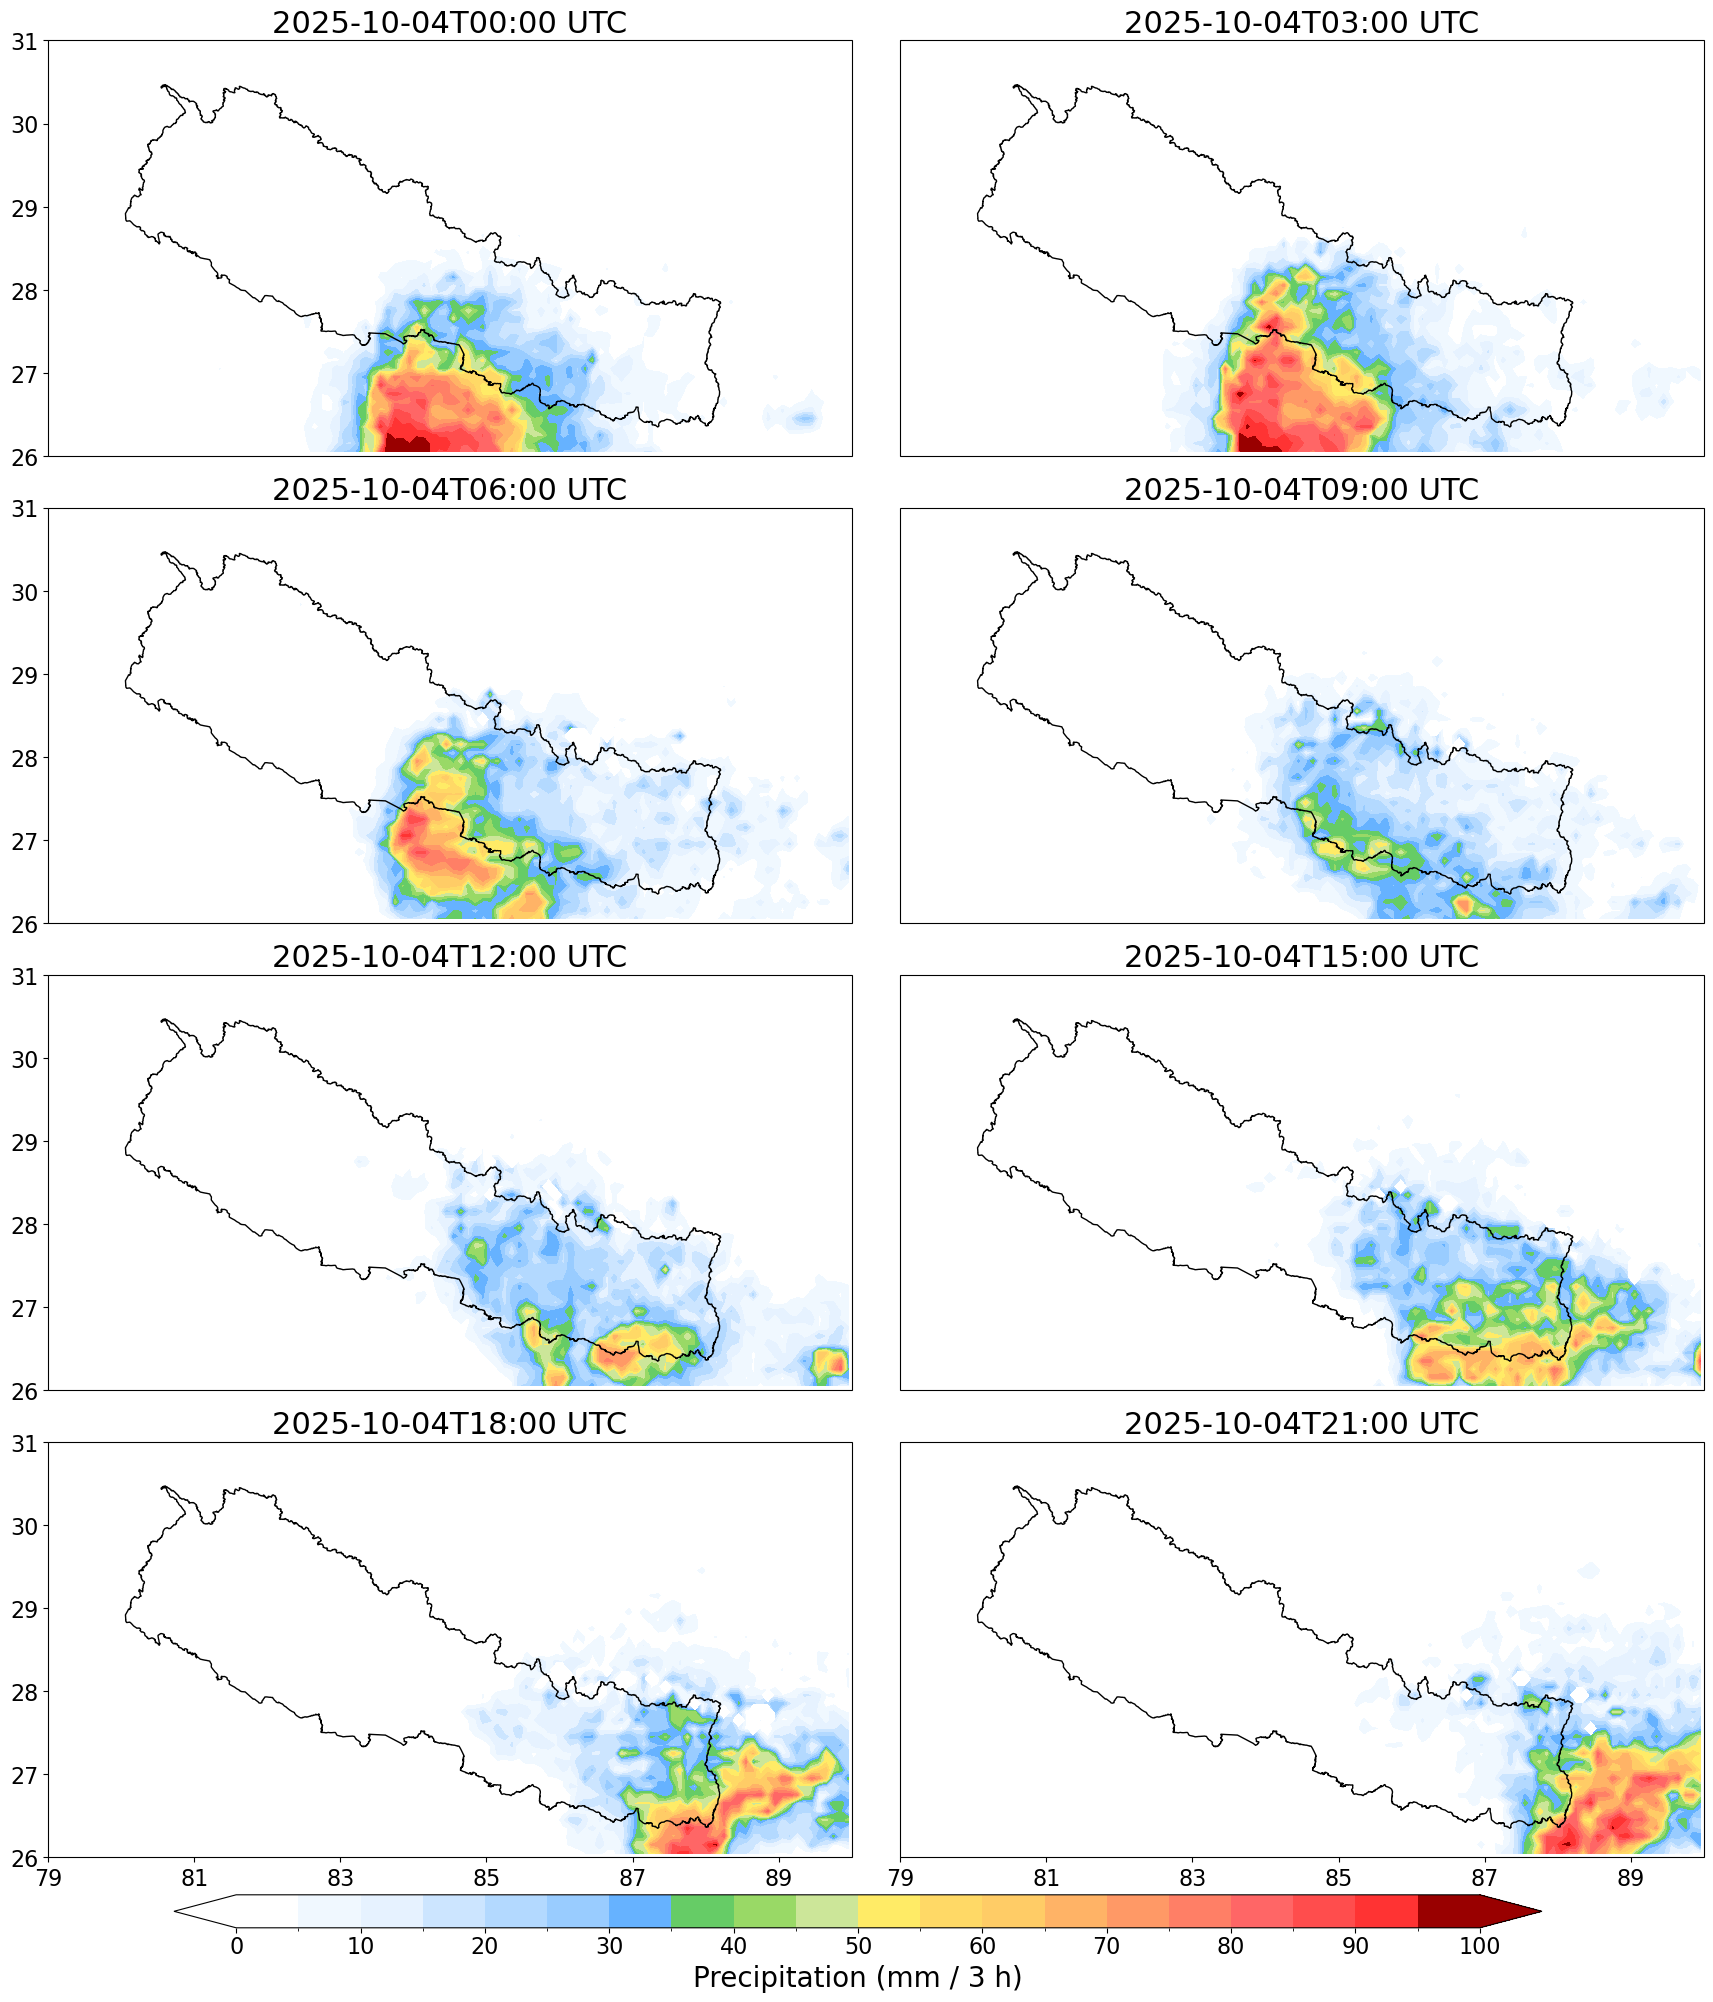

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import glob
import os
from matplotlib.colors import ListedColormap, BoundaryNorm

# -------------------------------------------------
# Folder with all NetCDF files
# -------------------------------------------------
nc_folder = '/Users/beekenshrestha/Downloads/RESEARCH/oct4/3h_MSWEP'
nc_files = sorted(glob.glob(os.path.join(nc_folder, '*.nc')))

# -------------------------------------------------
# Load shapefile
# -------------------------------------------------
shp_path = '/Users/beekenshrestha/Downloads/NPL/Nepal_shp/hermes_NPL_new_wgs_0.shp'
shp = gpd.read_file(shp_path)

# -------------------------------------------------
# Discrete custom colorbar
# -------------------------------------------------
bounds = np.array([
    0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100
])

colors = [
    "#ffffff", "#f0f8ff", "#e6f2ff", "#cce5ff", "#b3d9ff",
    "#99ccff", "#66b2ff", "#66cc66", "#99d966", "#cce699",
    "#ffff66", "#ffeb66", "#ffd966", "#ffcc66", "#ffb366",
    "#ff9966", "#ff7f66", "#ff6666", "#ff4d4d", "#ff3333",
    "#cc0000", "#990000"
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# -------------------------------------------------
# Prepare 4x2 panel (max 8 time steps)
# -------------------------------------------------
fig, axes = plt.subplots(
    4, 2, figsize=(18, 22),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# -------------------------------------------------
# Flatten all time steps across all files
# -------------------------------------------------
da_list = []
time_list = []

for f in nc_files:
    ds = xr.open_dataset(f)
    da = ds['precipitation']
    for t in da.time:
        da_list.append(da.sel(time=t))
        time_list.append(t)

n_panels = min(len(da_list), 8)

# -------------------------------------------------
# Plot each 3-hourly time step
# -------------------------------------------------
for i in range(n_panels):

    ax = axes[i]
    da2d = da_list[i]

    # Handle latitude order
    if da2d.lat[0] > da2d.lat[-1]:
        da2d = da2d.sel(lat=slice(31, 26), lon=slice(79, 90))
    else:
        da2d = da2d.sel(lat=slice(26, 31), lon=slice(79, 90))

    lat = da2d['lat'].values
    lon = da2d['lon'].values
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Mask zero precipitation
    da_masked = np.ma.masked_equal(da2d, 0)

    # Filled contours (DISCRETE)
    cf = ax.contourf(
        lon2d, lat2d, da_masked,
        levels=bounds,
        cmap=cmap,
        norm=norm,
        extend='both'
    )

    # Overlay Nepal boundary
    shp.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

    # Map extent
    ax.set_extent([79, 90, 26, 31], crs=ccrs.PlateCarree())

    # Latitude ticks only for left column
    if i % 2 == 0:
        ax.set_yticks(np.arange(26, 32, 1))
        ax.tick_params(axis='y', labelsize=16)
    else:
        ax.set_yticks([])

    # Longitude ticks only for bottom row
    if i >= 6:
        ax.set_xticks(np.arange(79, 91, 2))
        ax.tick_params(axis='x', labelsize=16)
    else:
        ax.set_xticks([])

    # Time title
    time_str = np.datetime_as_string(da2d['time'].values, unit='m')
    ax.set_title(f'{time_str} UTC', fontsize=22)

# -------------------------------------------------
# Hide unused subplots
# -------------------------------------------------
for j in range(n_panels, 8):
    axes[j].axis('off')

# -------------------------------------------------
# Horizontal colorbar (discrete)
# -------------------------------------------------
cbar_ax = fig.add_axes([0.12, 0.09, 0.76, 0.015])
cbar = fig.colorbar(
    cf,
    cax=cbar_ax,
    orientation='horizontal',
    ticks=bounds[::2]
)

cbar.set_label('Precipitation (mm / 3 h)', fontsize=20)
cbar.ax.tick_params(labelsize=16, pad=2)

# -------------------------------------------------
# Layout
# -------------------------------------------------
plt.subplots_adjust(
    left=0.05, right=0.97, top=0.95,
    bottom=0.12, wspace=0.06, hspace=0.10
)
plt.savefig("/Users/beekenshrestha/Downloads/RESEARCH/oct4/output/3h.png", dpi=1050, bbox_inches='tight')
plt.show()


In [2]:
data = xr.open_dataset('/Users/beekenshrestha/Downloads/RESEARCH/5yrs_oct4-6/MSWEP/merged.nc')

/opt/anaconda3/lib/python3.12/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.39.0 or higher is recommended. You are running version 2.33.0
  warnings.warn(


In [6]:
data

<xarray.Dataset> Size: 130MB
Dimensions:        (time: 5, lat: 1800, lon: 3600)
Coordinates:
  * lon            (lon) float32 14kB -179.9 -179.8 -179.8 ... 179.8 179.9 179.9
  * lat            (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * time           (time) datetime64[ns] 40B 2025-10-05 ... 2025-10-02
Data variables:
    precipitation  (time, lat, lon) float32 130MB ...

In [4]:
data['time']

<xarray.DataArray 'time' (time: 5)> Size: 40B
array(['2025-10-05T00:00:00.000000000', '2025-10-06T00:00:00.000000000',
       '2025-10-03T00:00:00.000000000', '2025-10-04T00:00:00.000000000',
       '2025-10-02T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 2025-10-05 2025-10-06 ... 2025-10-02

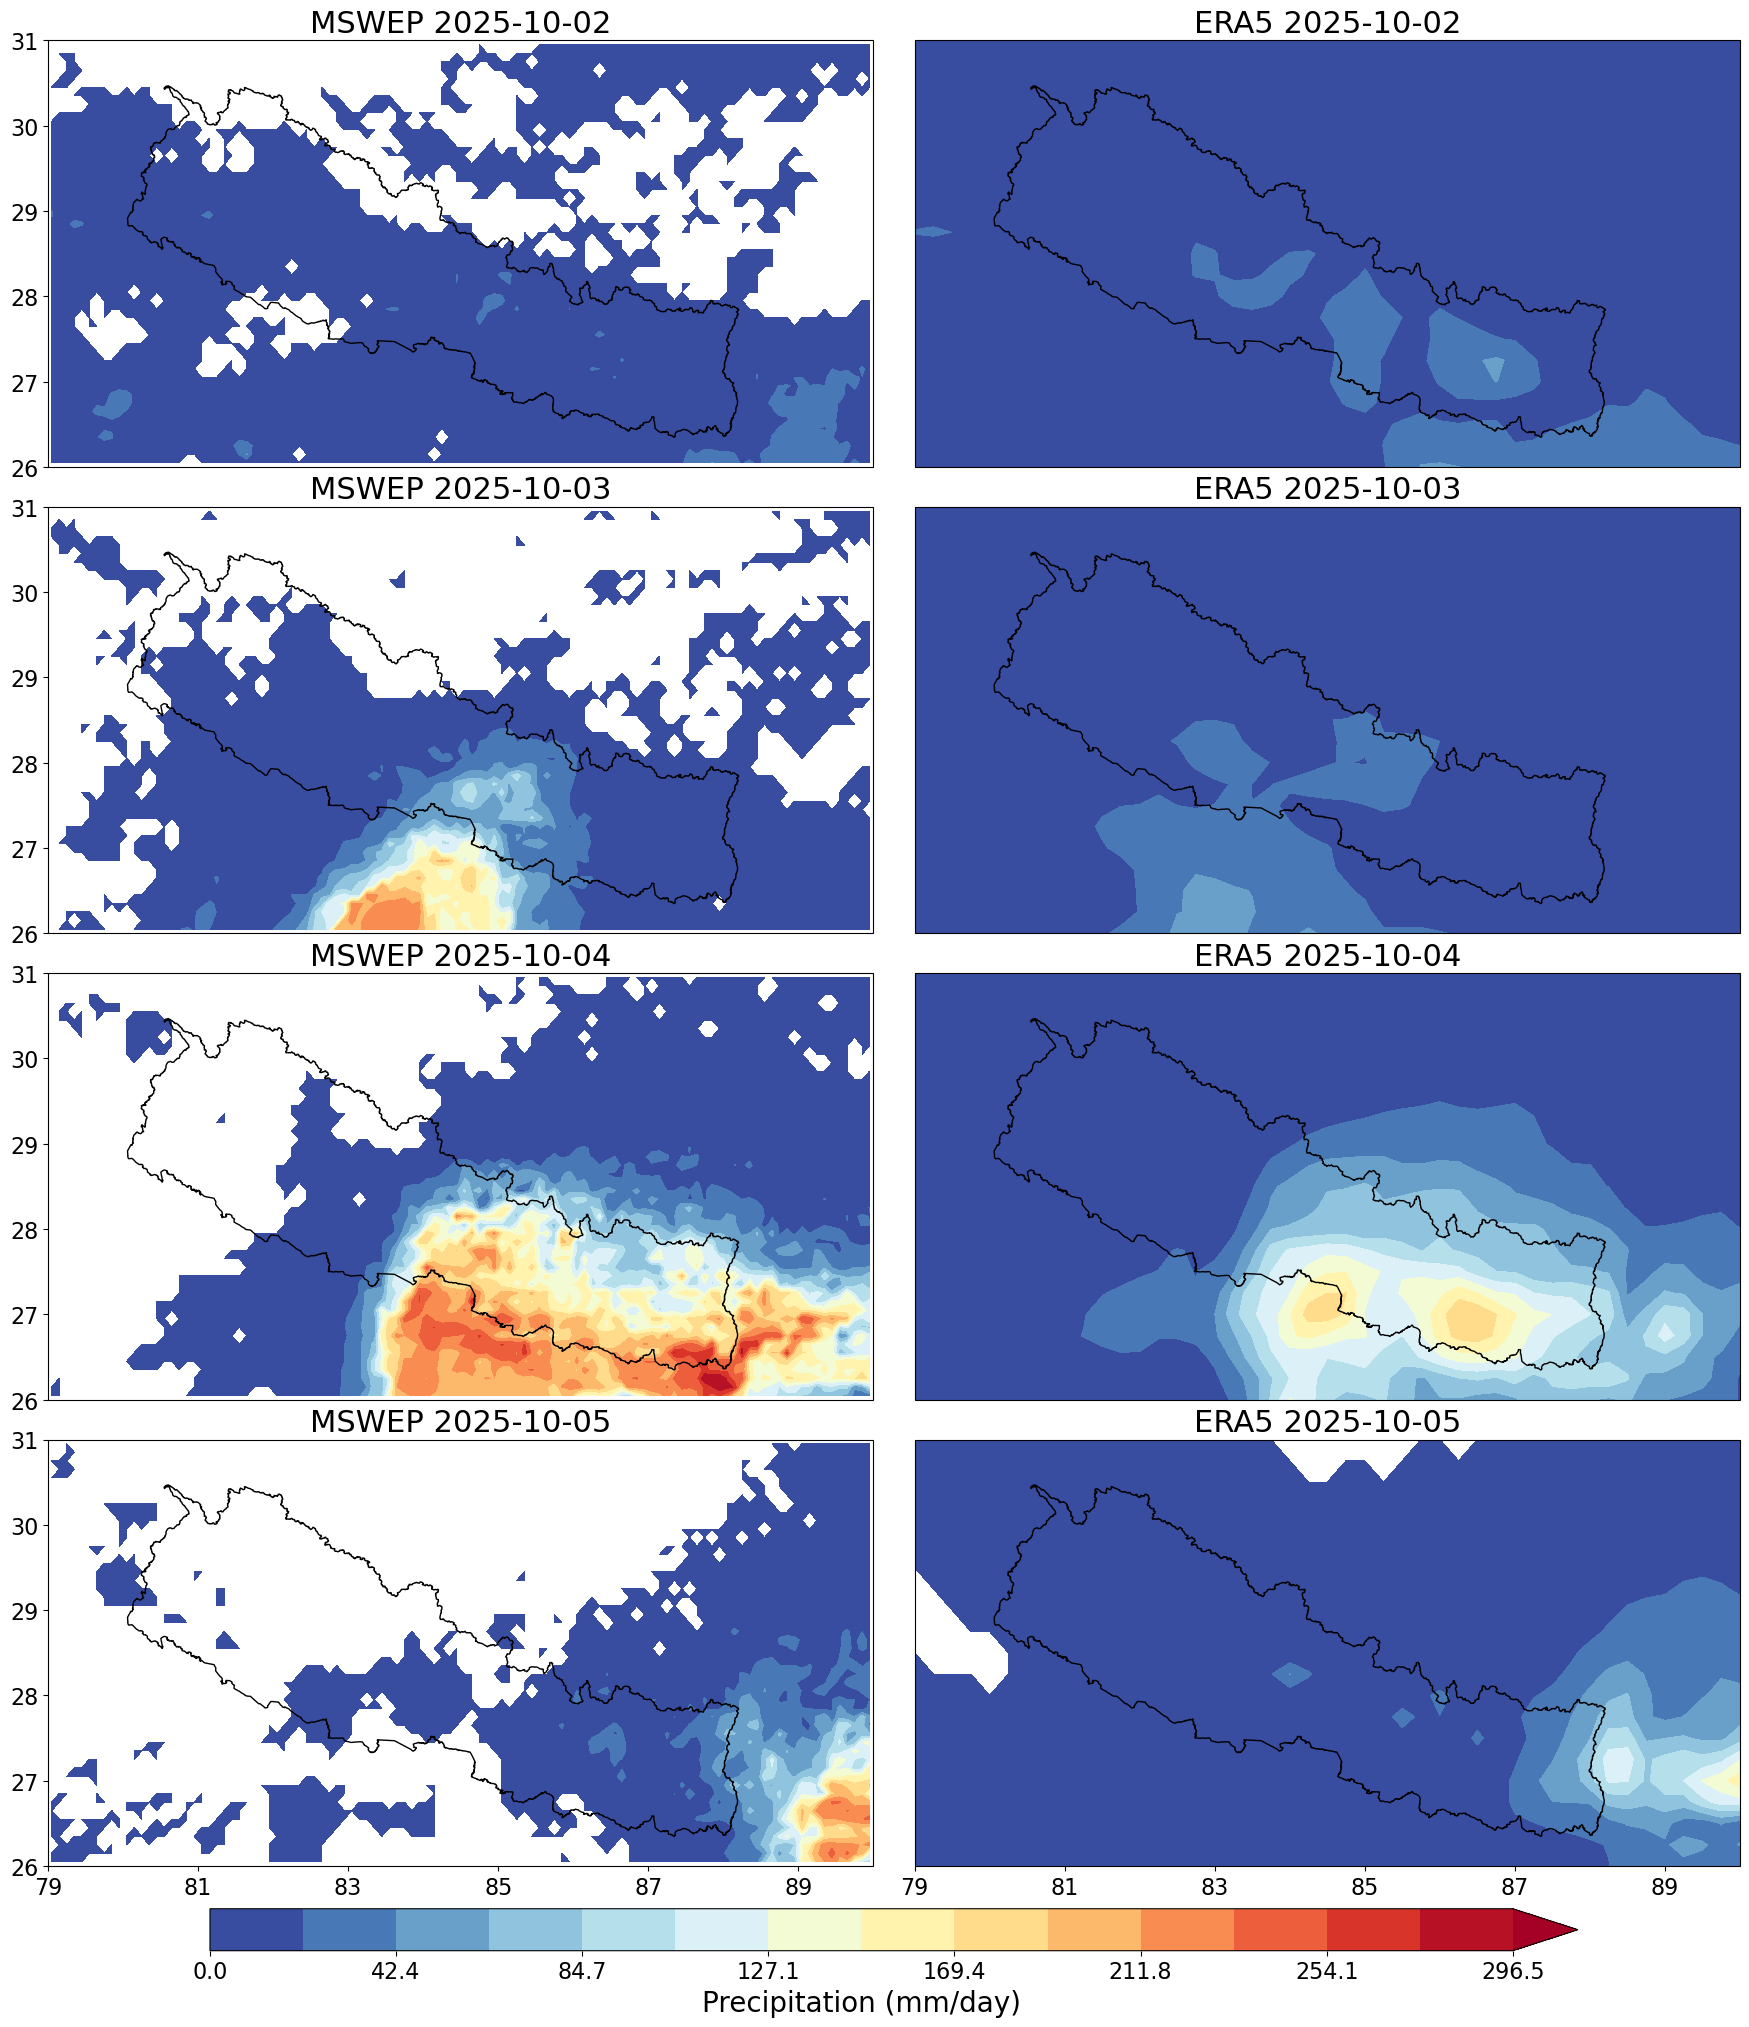

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import pandas as pd

# -------------------------------------------------
# Load shapefile
# -------------------------------------------------
shp_path = '/Users/beekenshrestha/Downloads/NPL/Nepal_shp/hermes_NPL_new_wgs_0.shp'
shp = gpd.read_file(shp_path)

# -------------------------------------------------
# Load MSWEP dataset
# -------------------------------------------------
mswep_file = '/Users/beekenshrestha/Downloads/RESEARCH/5yrs_oct4-6/MSWEP/merged.nc'
mswep = xr.open_dataset(mswep_file)['precipitation']

# Select year 2025 and Julian days 275–278 (10-02 to 10-05)
mswep_2025 = mswep.sel(time=mswep['time.year'] == 2025).sortby('time')
mswep_2025 = mswep_2025.isel(time=np.unique(mswep_2025['time'], return_index=True)[1])
mswep_subset = mswep_2025.sel(time=(mswep_2025['time.dayofyear'] >= 275) &
                              (mswep_2025['time.dayofyear'] <= 278))
mswep_daily = mswep_subset.resample(time='1D').sum()

# Handle latitude order
if mswep_daily.lat[0] > mswep_daily.lat[-1]:
    mswep_daily = mswep_daily.sel(lat=slice(31, 26))
else:
    mswep_daily = mswep_daily.sel(lat=slice(26, 31))
mswep_daily = mswep_daily.sel(lon=slice(79, 90))
mswep_lon2d, mswep_lat2d = np.meshgrid(mswep_daily.lon, mswep_daily.lat)

# -------------------------------------------------
# Load ERA5 dataset
# -------------------------------------------------
era5_file = '/Users/beekenshrestha/Downloads/RESEARCH/5yrs_oct4-6/ERA5/tp.nc'
ds = xr.open_dataset(era5_file, engine='netcdf4')
tp = ds['tp'] * 1000  # convert m → mm
time_dim = 'valid_time'

# Select 10-02 to 10-05
tp = tp.sel({time_dim: pd.to_datetime(tp[time_dim].values)})
dates_to_plot = ['10-02', '10-03', '10-04', '10-05']
tp_selected = tp.sel({time_dim: tp[time_dim].dt.strftime('%m-%d').isin(dates_to_plot)})

# Sum all hours per day
tp_daily_list = [tp_selected.sel({time_dim: tp_selected[time_dim].dt.strftime('%m-%d') == d}).sum(dim=time_dim)
                 for d in dates_to_plot]

# Handle latitude order
if tp_daily_list[0].latitude[0] > tp_daily_list[0].latitude[-1]:
    lat_slice_era5 = slice(31, 26)
else:
    lat_slice_era5 = slice(26, 31)
tp_daily_list = [da.sel(latitude=lat_slice_era5, longitude=slice(79, 90)) for da in tp_daily_list]
era5_lon2d, era5_lat2d = np.meshgrid(tp_daily_list[0]['longitude'], tp_daily_list[0]['latitude'])

# -------------------------------------------------
# Global min/max for color scale
# -------------------------------------------------
vmin = min(float(mswep_daily.min()), min([float(da.min()) for da in tp_daily_list]))
vmax = max(float(mswep_daily.max()), max([float(da.max()) for da in tp_daily_list]))
levels = np.linspace(vmin, vmax, 15)
cmap = plt.cm.RdYlBu_r

# -------------------------------------------------
# 4x2 Panel: Left=MSWEP, Right=ERA5
# -------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(18, 21), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Tick ranges
lon_min, lon_max = 79, 90
lat_min, lat_max = 26, 31

for i, day in enumerate(dates_to_plot):
    # ---- Left column: MSWEP ----
    ax_left = axes[2*i]
    mswep_day = mswep_daily.sel(time=mswep_daily.time.dt.strftime('%m-%d') == day).squeeze()
    mswep_masked = np.ma.masked_equal(mswep_day, 0)
    cf = ax_left.contourf(mswep_lon2d, mswep_lat2d, mswep_masked, levels=levels, cmap=cmap, extend='max')
    shp.plot(ax=ax_left, facecolor='none', edgecolor='black', linewidth=1)
    ax_left.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax_left.set_yticks(np.arange(lat_min, lat_max+1, 1))  # Latitude ticks for left column
    ax_left.tick_params(axis='y', labelsize=16)  # bigger y-tick labels
    ax_left.set_title(f'MSWEP 2025-{day}', fontsize=22)  # bigger title

    # ---- Right column: ERA5 ----
    ax_right = axes[2*i+1]
    era5_day = tp_daily_list[i].squeeze()
    era5_masked = np.ma.masked_equal(era5_day, 0)
    cf = ax_right.contourf(era5_lon2d, era5_lat2d, era5_masked, levels=levels, cmap=cmap, extend='max')
    shp.plot(ax=ax_right, facecolor='none', edgecolor='black', linewidth=1)
    ax_right.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax_right.set_yticks([])  # No latitude ticks for right column
    ax_right.set_title(f'ERA5 2025-{day}', fontsize=22)  # bigger title

    # Longitude ticks only for bottom row
    if i == 3:
        ax_left.set_xticks(np.arange(lon_min, lon_max+1, 2))
        ax_left.tick_params(axis='x', labelsize=16)  # bigger x-tick labels
        ax_right.set_xticks(np.arange(lon_min, lon_max+1, 2))
        ax_right.tick_params(axis='x', labelsize=16)  # bigger x-tick labels
    else:
        ax_left.set_xticks([])
        ax_right.set_xticks([])

cbar_ax = fig.add_axes([0.12, 0.04, 0.76, 0.02])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Precipitation (mm/day)', fontsize=20)
cbar.ax.tick_params(labelsize=16)

plt.subplots_adjust(left=0.03, right=0.97, top=0.95, bottom=0.08, wspace=0.05, hspace=0.09)
plt.show()


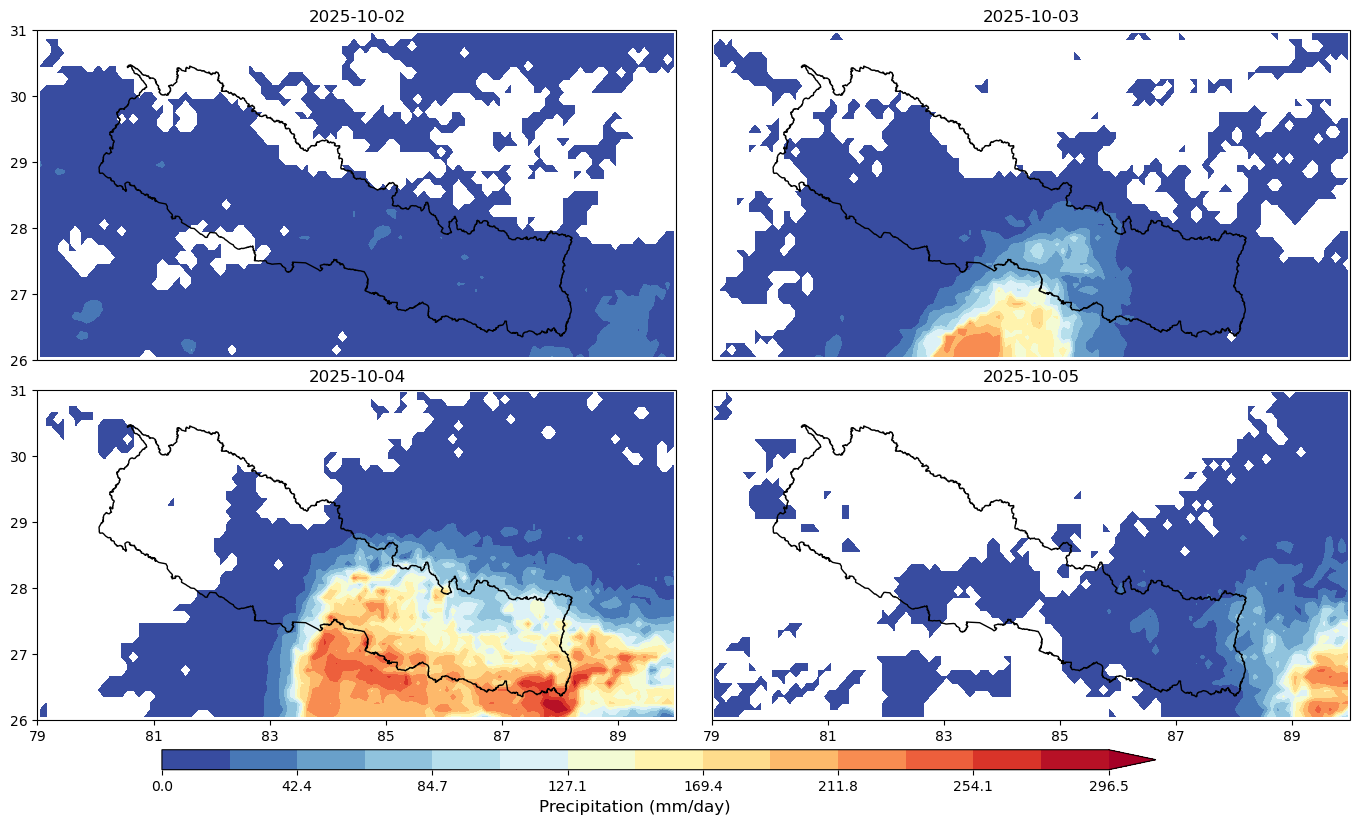

In [49]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd

# -------------------------------------------------
# Load MSWEP precipitation dataset
# -------------------------------------------------
data = xr.open_dataset('/Users/beekenshrestha/Downloads/RESEARCH/5yrs_oct4-6/MSWEP/merged.nc')
precip = data['precipitation']

# -------------------------------------------------
# Select year 2025 and Julian days 275–279
# -------------------------------------------------
precip_2025 = precip.sel(time=precip['time.year'] == 2025)
precip_subset = precip_2025.sel(time=(precip_2025['time.dayofyear'] >= 275) &
                                (precip_2025['time.dayofyear'] <= 279))
precip_subset = precip_subset.sortby('time')
precip_daily = precip_subset.resample(time='1D').sum()

# -------------------------------------------------
# Exclude last day (2025-10-06)
# -------------------------------------------------
precip_daily = precip_daily.sel(time=precip_daily.time != np.datetime64('2025-10-06'))

# -------------------------------------------------
# Handle latitude order
# -------------------------------------------------
if precip_daily.lat[0] > precip_daily.lat[-1]:
    precip_daily = precip_daily.sel(lat=slice(31, 26), lon=slice(79, 90))
else:
    precip_daily = precip_daily.sel(lat=slice(26, 31), lon=slice(79, 90))

# -------------------------------------------------
# Load shapefile
# -------------------------------------------------
shp_path = '/Users/beekenshrestha/Downloads/NPL/Nepal_shp/hermes_NPL_new_wgs_0.shp'
shp = gpd.read_file(shp_path)

# -------------------------------------------------
# Lat/Lon grids
# -------------------------------------------------
lat = precip_daily['lat'].values
lon = precip_daily['lon'].values
lon2d, lat2d = np.meshgrid(lon, lat)

# -------------------------------------------------
# 2x2 panel plot
# -------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Colormap and levels
vmin = float(precip_daily.min())
vmax = float(precip_daily.max())
levels = np.linspace(vmin, vmax, 15)
cmap = plt.cm.RdYlBu_r

# Plot each day's precipitation
for i, t in enumerate(precip_daily.time):
    ax = axes[i]
    day = np.datetime_as_string(t.values, unit='D')
    precip_day = precip_daily.sel(time=t)

    # Mask zero values to white
    precip_masked = np.ma.masked_equal(precip_day, 0)

    # Filled contour
    cf = ax.contourf(lon2d, lat2d, precip_masked,
                     levels=levels, cmap=cmap, extend='max')

    # Overlay shapefile
    shp.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

    # Set extent
    ax.set_extent([79, 90, 26, 31], crs=ccrs.PlateCarree())

    # Latitude ticks only for first column
    if i % 2 == 0:
        ax.set_yticks(np.arange(26, 32, 1))
        ax.tick_params(axis='y', labelsize=10)
    else:
        ax.set_yticks([])

    # Longitude ticks only for last row
    if i >= 2:
        ax.set_xticks(np.arange(79, 91, 2))
        ax.tick_params(axis='x', labelsize=10)
    else:
        ax.set_xticks([])

    # Title
    ax.set_title(day, fontsize=12)

# Horizontal colorbar
cbar_ax = fig.add_axes([0.12, 0.08, 0.71, 0.02])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Precipitation (mm/day)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Small uniform gap between subplots
plt.subplots_adjust(left=0.03, right=0.97, top=0.82, bottom=0.13, wspace=0.05, hspace=0.09)
plt.show()


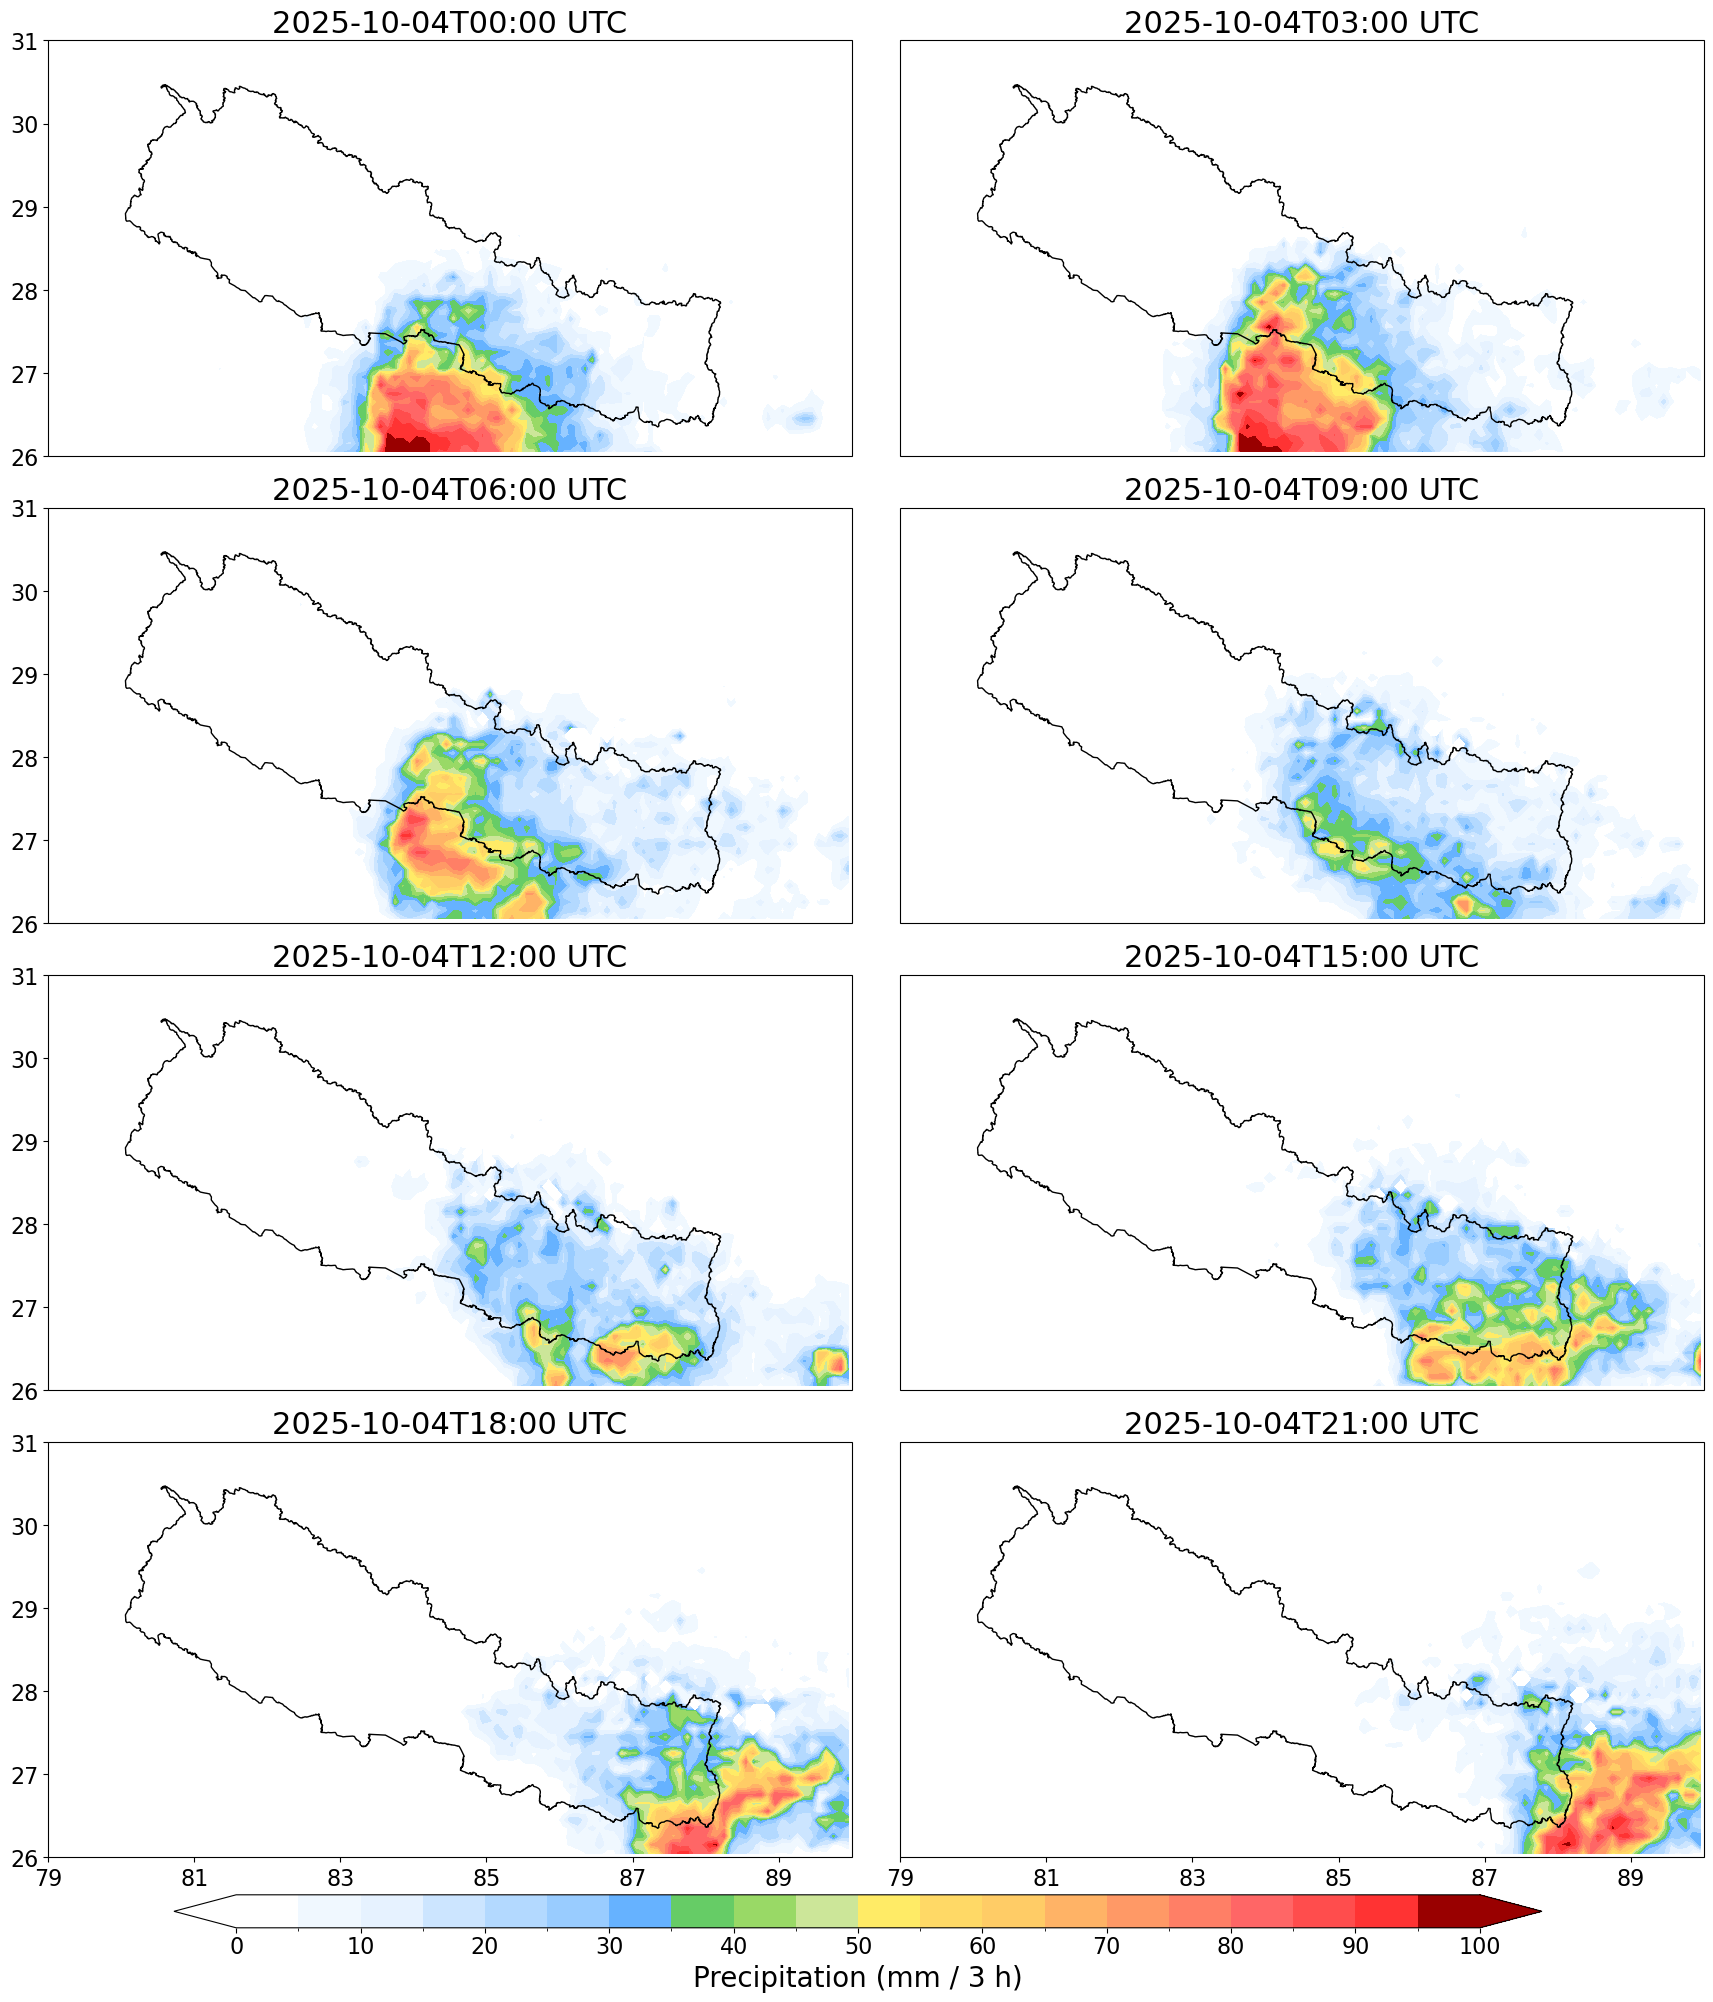

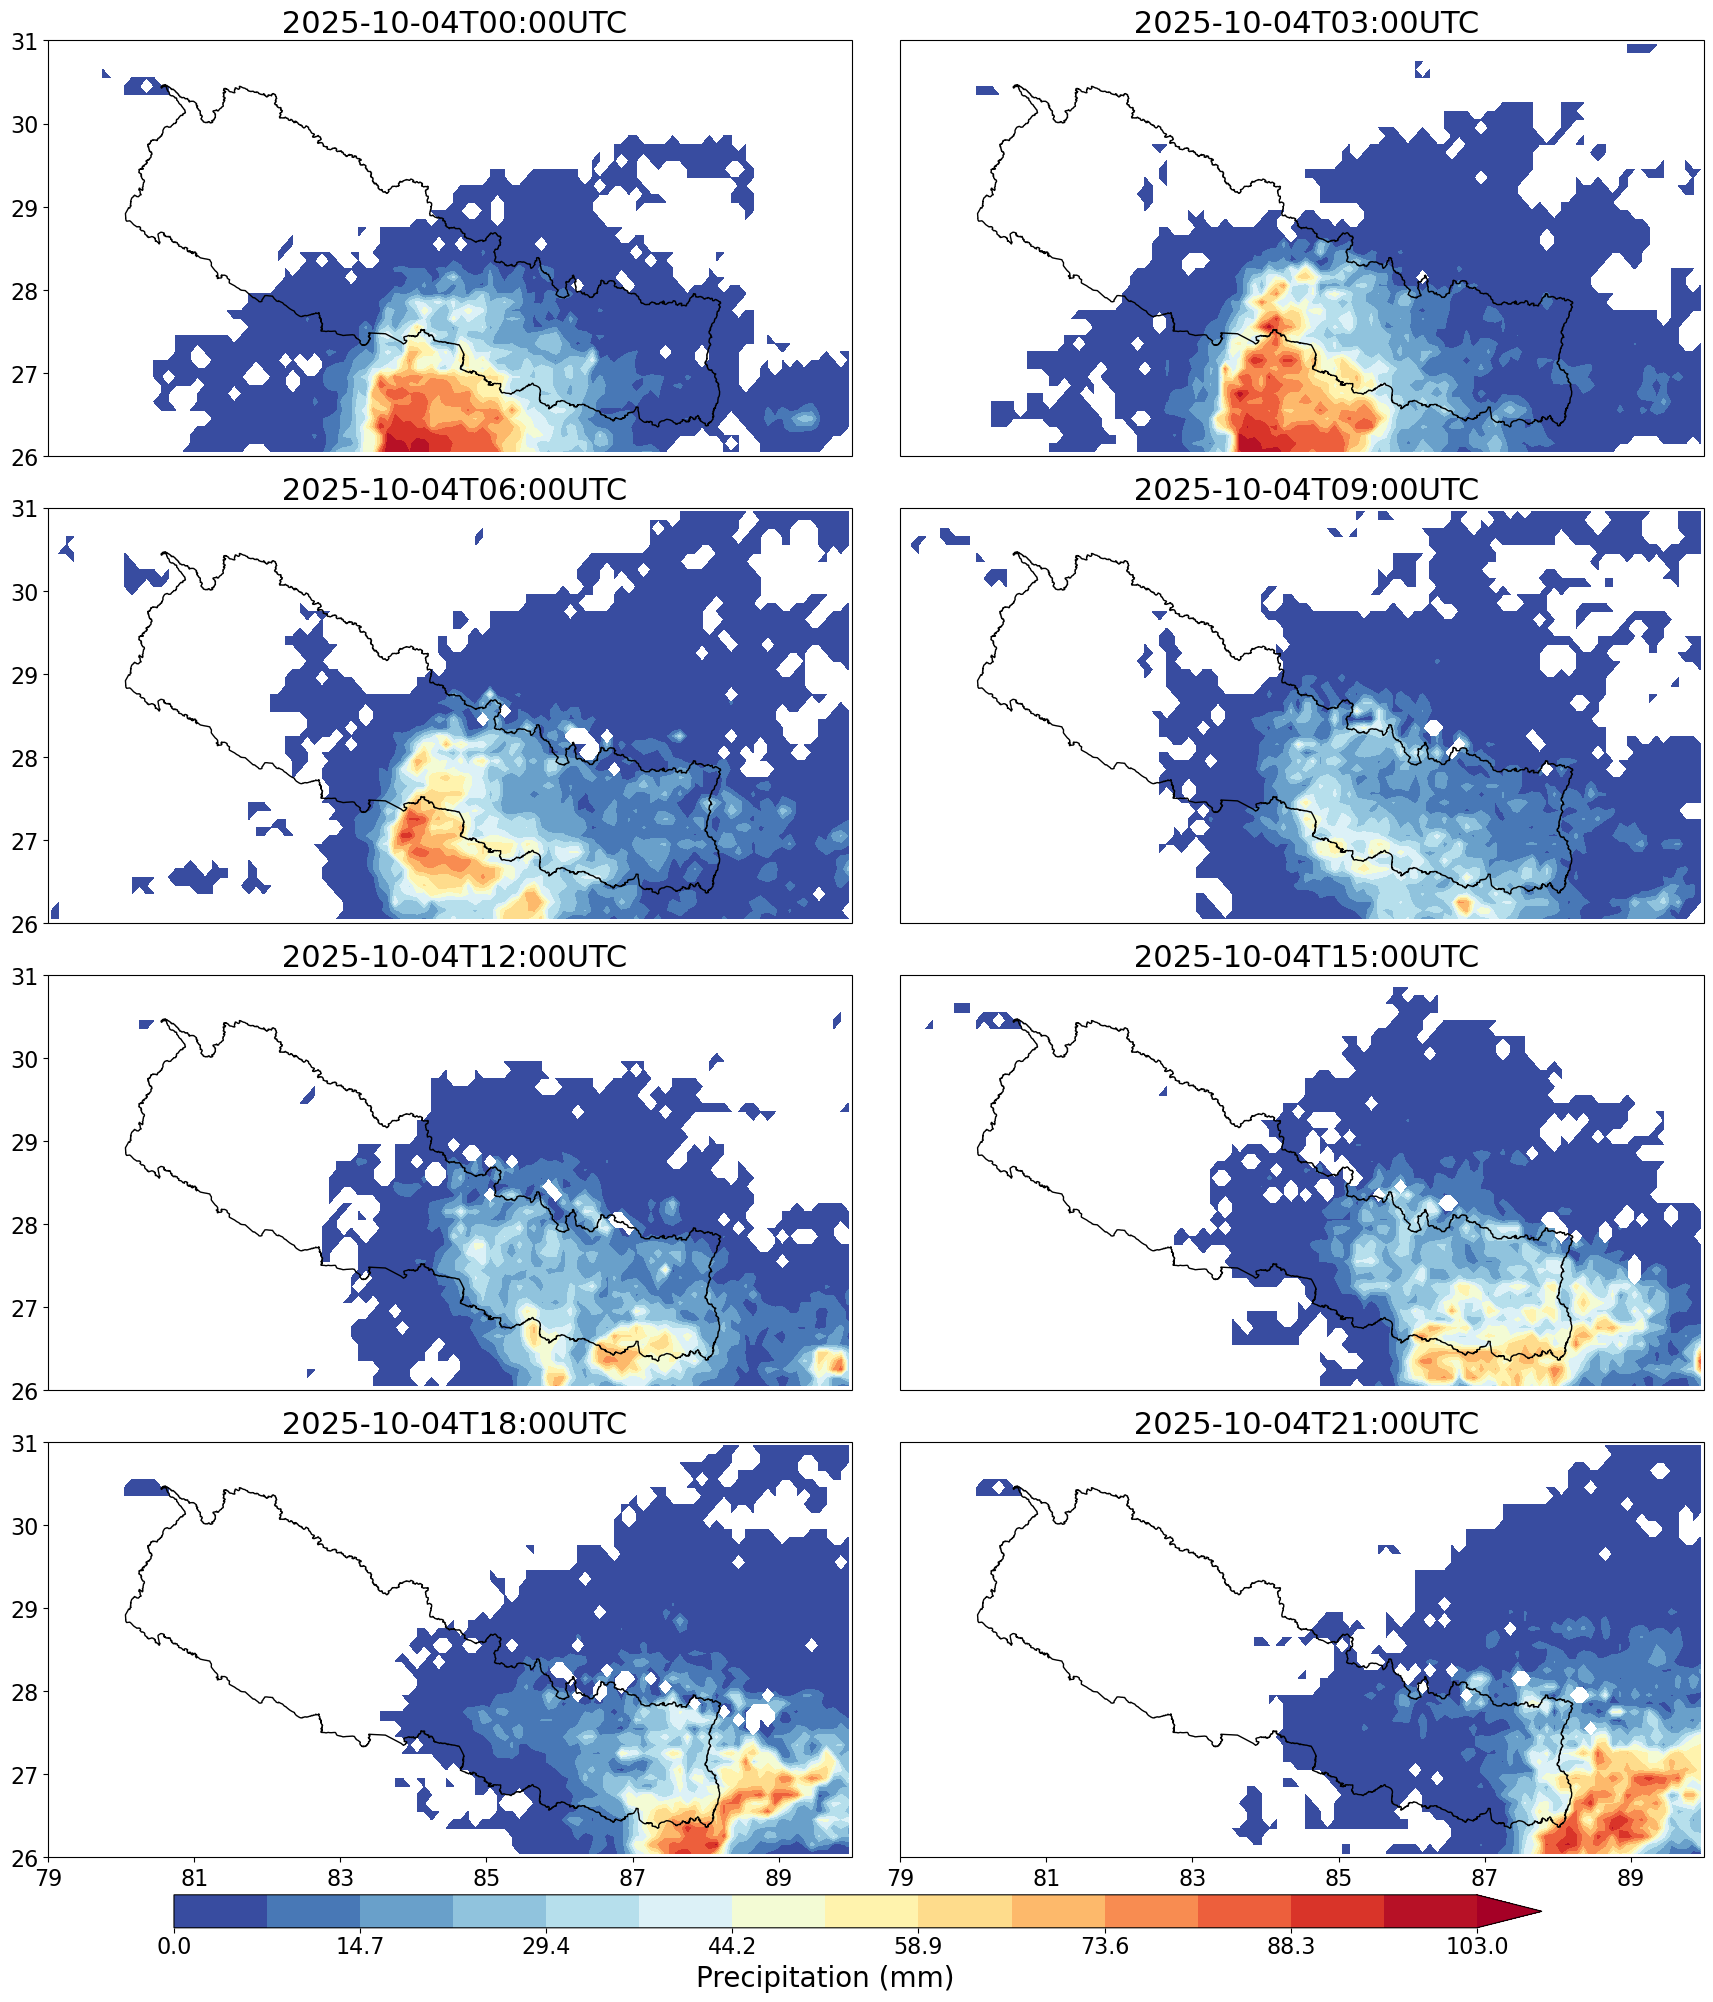

In [55]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import glob
import os

# -------------------------------------------------
# Folder with all NetCDF files
# -------------------------------------------------
nc_folder = '/Users/beekenshrestha/Downloads/RESEARCH/5yrs_oct4-6/3h_MSWEP'
nc_files = sorted(glob.glob(os.path.join(nc_folder, '*.nc')))

# -------------------------------------------------
# Load shapefile
# -------------------------------------------------
shp_path = '/Users/beekenshrestha/Downloads/NPL/Nepal_shp/hermes_NPL_new_wgs_0.shp'
shp = gpd.read_file(shp_path)

# -------------------------------------------------
# Prepare 4x2 panel (8 time steps max)
# -------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(18, 22),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# -------------------------------------------------
# Flatten all times across files
# -------------------------------------------------
time_list = []
da_list = []
for f in nc_files:
    da = xr.open_dataset(f)['precipitation']
    for t in da.time:
        da_list.append(da.sel(time=t))
        time_list.append(t)

n_panels = min(len(time_list), 8)  # plot up to 8 time steps

# -------------------------------------------------
# Determine global min/max for all time steps
# -------------------------------------------------
all_min = min([float(da.min()) for da in da_list[:n_panels]])
all_max = max([float(da.max()) for da in da_list[:n_panels]])
levels = np.linspace(all_min, all_max, 15)
cmap = plt.cm.RdYlBu_r

# -------------------------------------------------
# Plot each time step
# -------------------------------------------------
for i in range(n_panels):
    ax = axes[i]
    da2d = da_list[i]

    # Handle latitude order
    if da2d.lat[0] > da2d.lat[-1]:
        da2d = da2d.sel(lat=slice(31, 26), lon=slice(79, 90))
    else:
        da2d = da2d.sel(lat=slice(26, 31), lon=slice(79, 90))

    lat = da2d['lat'].values
    lon = da2d['lon'].values
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Mask zero values
    da_masked = np.ma.masked_equal(da2d, 0)

    # Filled contour
    cf = ax.contourf(lon2d, lat2d, da_masked, levels=levels, cmap=cmap, extend='max')

    # Overlay shapefile
    shp.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

    # Set extent
    ax.set_extent([79, 90, 26, 31], crs=ccrs.PlateCarree())

    # Latitude ticks for first column
    if i % 2 == 0:
        ax.set_yticks(np.arange(26, 32, 1))
        ax.tick_params(axis='y', labelsize=16)
    else:
        ax.set_yticks([])

    # Longitude ticks for last row
    if i >= 6:
        ax.set_xticks(np.arange(79, 91, 2))
        ax.tick_params(axis='x', labelsize=16)
    else:
        ax.set_xticks([])

    # Title for each time step
    start_time = str(da2d['time'].values)[:16]
    ax.set_title(f' {start_time}UTC', fontsize=22)

# Hide unused subplots
for j in range(n_panels, 8):
    axes[j].axis('off')

# Horizontal colorbar – smaller height
cbar_ax = fig.add_axes([0.12, 0.09, 0.76, 0.015])  # [left, bottom, width, height] (height reduced)
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal', label='Precipitation (mm)')
cbar.ax.tick_params(labelsize=16, pad=2)  # smaller tick labels, adjust pad if needed
cbar.set_label('Precipitation (mm)', fontsize=20)  # smaller label

# Adjust spacing
plt.subplots_adjust(left=0.05, right=0.97, top=0.95, bottom=0.12, wspace=0.06, hspace=0.1)
plt.show()


/var/folders/jv/b201cczs5pj2c3krlgyf3fs80000gn/T/ipykernel_1669/1358620348.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(
/var/folders/jv/b201cczs5pj2c3krlgyf3fs80000gn/T/ipykernel_1669/1358620348.py:143: UserWarning: Adding colorbar to a different Figure <Figure size 1800x700 with 4 Axes> than <Figure size 1800x2200 with 9 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(


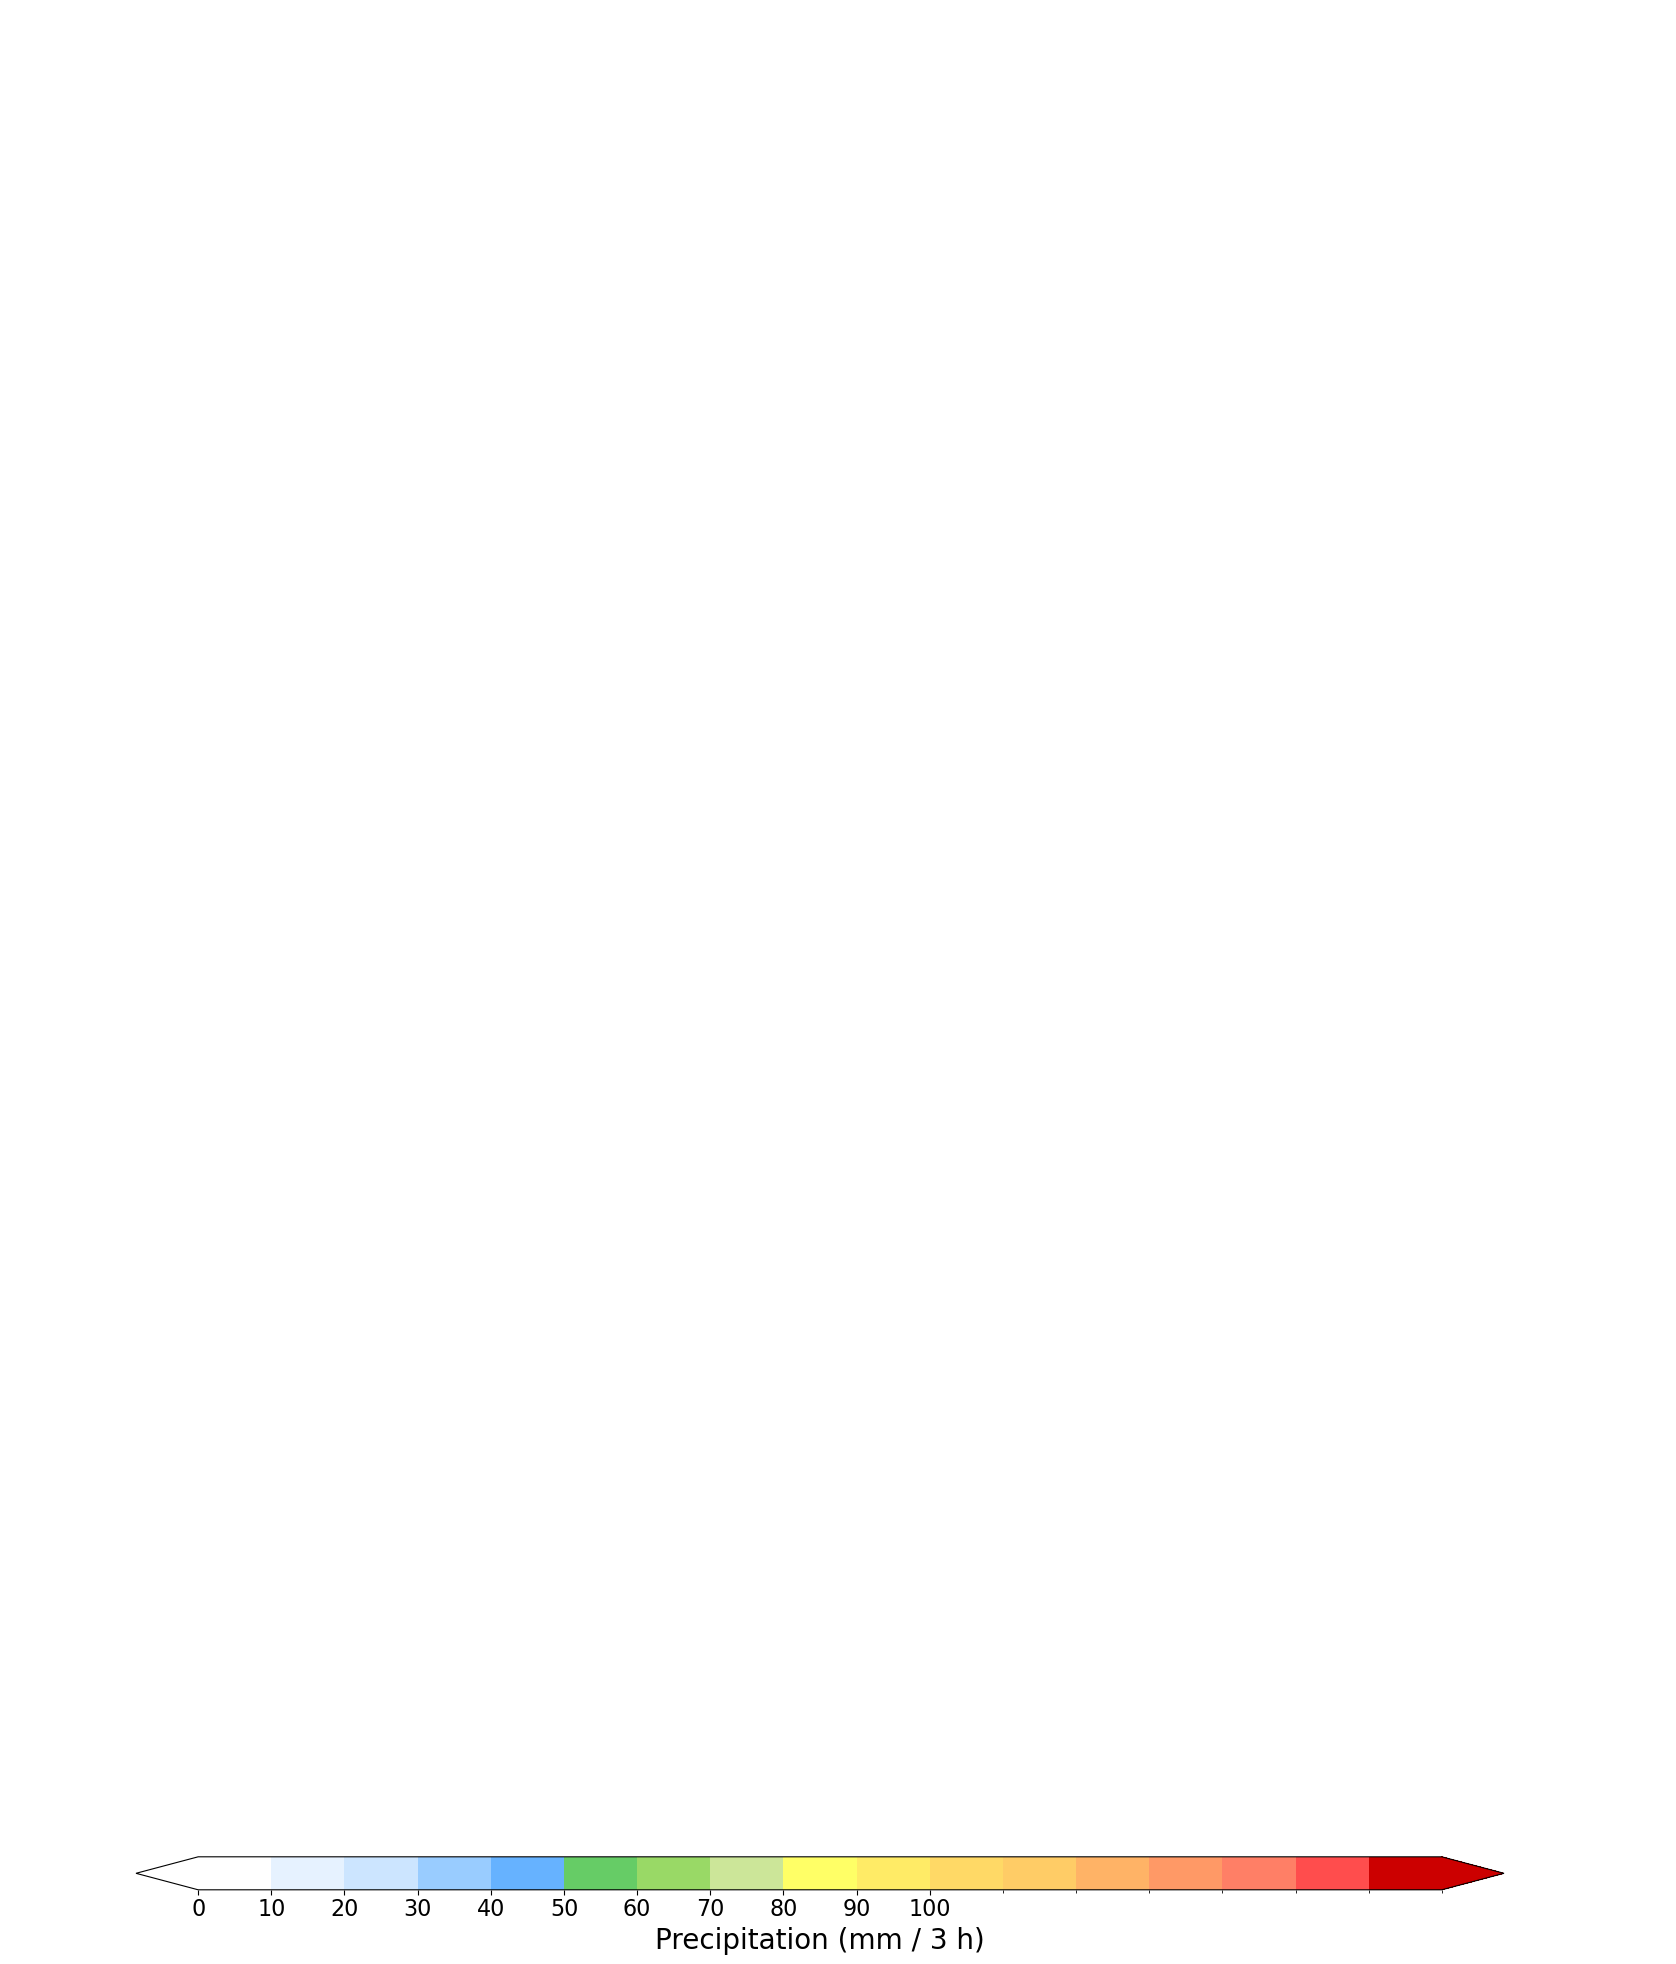

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import glob
import os
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm

# -------------------------------------------------
# Folder with all NetCDF files
# -------------------------------------------------
nc_folder = '/Users/beekenshrestha/Downloads/RESEARCH/oct4/3h_MSWEP31'
nc_files = sorted(glob.glob(os.path.join(nc_folder, '*.nc')))

# -------------------------------------------------
# Load shapefile
# -------------------------------------------------
shp_path = '/Users/beekenshrestha/Downloads/NPL/Nepal_shp/hermes_NPL_new_wgs_0.shp'
shp = gpd.read_file(shp_path)

# -------------------------------------------------
# Target times: 2025-10-31 every 3 hours
# -------------------------------------------------
target_times = pd.date_range(
    start="2025-10-31 00:00",
    end="2025-10-31 21:00",
    freq="3H"
)

# -------------------------------------------------
# Discrete custom colorbar
# -------------------------------------------------
bounds = np.array([
    0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100
])

colors = [
    "#ffffff", "#f0f8ff", "#e6f2ff", "#cce5ff", "#b3d9ff",
    "#99ccff", "#66b2ff", "#66cc66", "#99d966", "#cce699",
    "#ffff66", "#ffeb66", "#ffd966", "#ffcc66", "#ffb366",
    "#ff9966", "#ff7f66", "#ff6666", "#ff4d4d", "#ff3333",
    "#cc0000", "#990000"
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# -------------------------------------------------
# Prepare 4x2 panel (8 time steps)
# -------------------------------------------------
fig, axes = plt.subplots(
    4, 2, figsize=(18, 22),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# -------------------------------------------------
# Read only required time steps
# -------------------------------------------------
da_list = []

for f in nc_files:
    ds = xr.open_dataset(f)
    da = ds['precipitation']

    # Select only 2025-10-31 3-hourly data
    da_sel = da.sel(time=da.time.isin(target_times))

    for t in da_sel.time:
        da_list.append(da_sel.sel(time=t))

# Ensure chronological order
da_list = sorted(da_list, key=lambda x: x.time.values)

n_panels = min(len(da_list), 8)

# -------------------------------------------------
# Plot each 3-hourly time step
# -------------------------------------------------
for i in range(n_panels):

    ax = axes[i]
    da2d = da_list[i]

    # Handle latitude order
    if da2d.lat[0] > da2d.lat[-1]:
        da2d = da2d.sel(lat=slice(31, 26), lon=slice(79, 90))
    else:
        da2d = da2d.sel(lat=slice(26, 31), lon=slice(79, 90))

    lat = da2d['lat'].values
    lon = da2d['lon'].values
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Mask zero precipitation
    da_masked = np.ma.masked_equal(da2d, 0)

    # Filled contours (DISCRETE)
    cf = ax.contourf(
        lon2d, lat2d, da_masked,
        levels=bounds,
        cmap=cmap,
        norm=norm,
        extend='both'
    )

    # Overlay Nepal boundary
    shp.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

    # Map extent
    ax.set_extent([79, 90, 26, 31], crs=ccrs.PlateCarree())

    # Latitude ticks (left column only)
    if i % 2 == 0:
        ax.set_yticks(np.arange(26, 32, 1))
        ax.tick_params(axis='y', labelsize=16)
    else:
        ax.set_yticks([])

    # Longitude ticks (bottom row only)
    if i >= 6:
        ax.set_xticks(np.arange(79, 91, 2))
        ax.tick_params(axis='x', labelsize=16)
    else:
        ax.set_xticks([])

    # Time title
    time_str = np.datetime_as_string(da2d.time.values, unit='m')
    ax.set_title(f'{time_str} UTC', fontsize=22)

# -------------------------------------------------
# Hide unused subplots
# -------------------------------------------------
for j in range(n_panels, 8):
    axes[j].axis('off')

# -------------------------------------------------
# Horizontal colorbar
# -------------------------------------------------
cbar_ax = fig.add_axes([0.12, 0.09, 0.76, 0.015])
cbar = fig.colorbar(
    cf,
    cax=cbar_ax,
    orientation='horizontal',
    ticks=bounds[::2]
)

cbar.set_label('Precipitation (mm / 3 h)', fontsize=20)
cbar.ax.tick_params(labelsize=16, pad=2)

# -------------------------------------------------
# Layout
# -------------------------------------------------
plt.subplots_adjust(
    left=0.05, right=0.97, top=0.95,
    bottom=0.12, wspace=0.06, hspace=0.10
)

plt.show()


In [ ]:
ds

/var/folders/jv/b201cczs5pj2c3krlgyf3fs80000gn/T/ipykernel_1669/2576994826.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


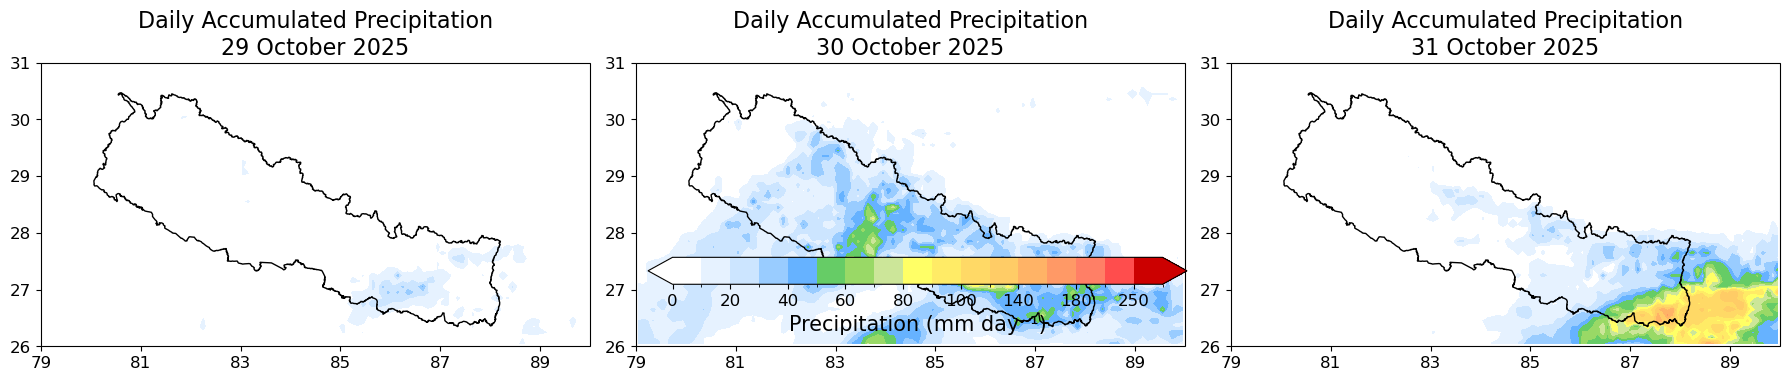

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import glob
import os
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm

# -------------------------------------------------
# Folder with all NetCDF files
# -------------------------------------------------
nc_folder = '/Users/beekenshrestha/Downloads/RESEARCH/oct4/3h_MSWEP31'
nc_files = sorted(glob.glob(os.path.join(nc_folder, '*.nc')))

# -------------------------------------------------
# Load shapefile
# -------------------------------------------------
shp_path = '/Users/beekenshrestha/Downloads/NPL/Nepal_shp/hermes_NPL_new_wgs_0.shp'
shp = gpd.read_file(shp_path)

# -------------------------------------------------
# Date range
# -------------------------------------------------
start_date = "2025-10-29"
end_date   = "2025-10-31"

dates = pd.date_range(start=start_date, end=end_date, freq="D")

# -------------------------------------------------
# Discrete colorbar (daily accumulation)
# -------------------------------------------------
bounds = np.array([
    0,10,20,30,40,50,60,70,80,90,100,
    120,140,160,180,200,250,300
])

colors = [
    "#ffffff", "#e6f2ff", "#cce5ff", "#99ccff", "#66b2ff",
    "#66cc66", "#99d966", "#cce699", "#ffff66", "#ffeb66",
    "#ffd966", "#ffcc66", "#ffb366", "#ff9966",
    "#ff7f66", "#ff4d4d", "#cc0000"
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# -------------------------------------------------
# Read all precipitation data (once)
# -------------------------------------------------
da_all = []

for f in nc_files:
    ds = xr.open_dataset(f)
    da_all.append(ds['precipitation'])

da_all = xr.concat(da_all, dim='time').sortby('time')

# -------------------------------------------------
# Prepare panels (one per day)
# -------------------------------------------------
n_days = len(dates)

fig, axes = plt.subplots(
    1, n_days,
    figsize=(6*n_days, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

if n_days == 1:
    axes = [axes]

# -------------------------------------------------
# Loop through each day
# -------------------------------------------------
for i, day in enumerate(dates):

    ax = axes[i]

    # Select that day
    da_day = da_all.sel(
        time=da_all.time.dt.strftime('%Y-%m-%d') == day.strftime('%Y-%m-%d')
    )

    # Daily accumulation
    da_daily = da_day.sum(dim='time')

    # Spatial subsetting
    if da_daily.lat[0] > da_daily.lat[-1]:
        da_daily = da_daily.sel(lat=slice(31, 26), lon=slice(79, 90))
    else:
        da_daily = da_daily.sel(lat=slice(26, 31), lon=slice(79, 90))

    lat = da_daily['lat'].values
    lon = da_daily['lon'].values
    lon2d, lat2d = np.meshgrid(lon, lat)

    da_masked = np.ma.masked_equal(da_daily.values, 0)

    cf = ax.contourf(
        lon2d, lat2d, da_masked,
        levels=bounds,
        cmap=cmap,
        norm=norm,
        extend='both'
    )

    shp.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

    ax.set_extent([79, 90, 26, 31], crs=ccrs.PlateCarree())
    ax.set_xticks(np.arange(79, 91, 2))
    ax.set_yticks(np.arange(26, 32, 1))
    ax.tick_params(labelsize=12)

    ax.set_title(
        f'Daily Accumulated Precipitation\n{day.strftime("%d %B %Y")}',
        fontsize=16
    )

# -------------------------------------------------
# Colorbar
# -------------------------------------------------
cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation='horizontal',
    fraction=0.05,
    pad=0.08,
    ticks=bounds[::2]
)

cbar.set_label('Precipitation (mm day⁻¹)', fontsize=15)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


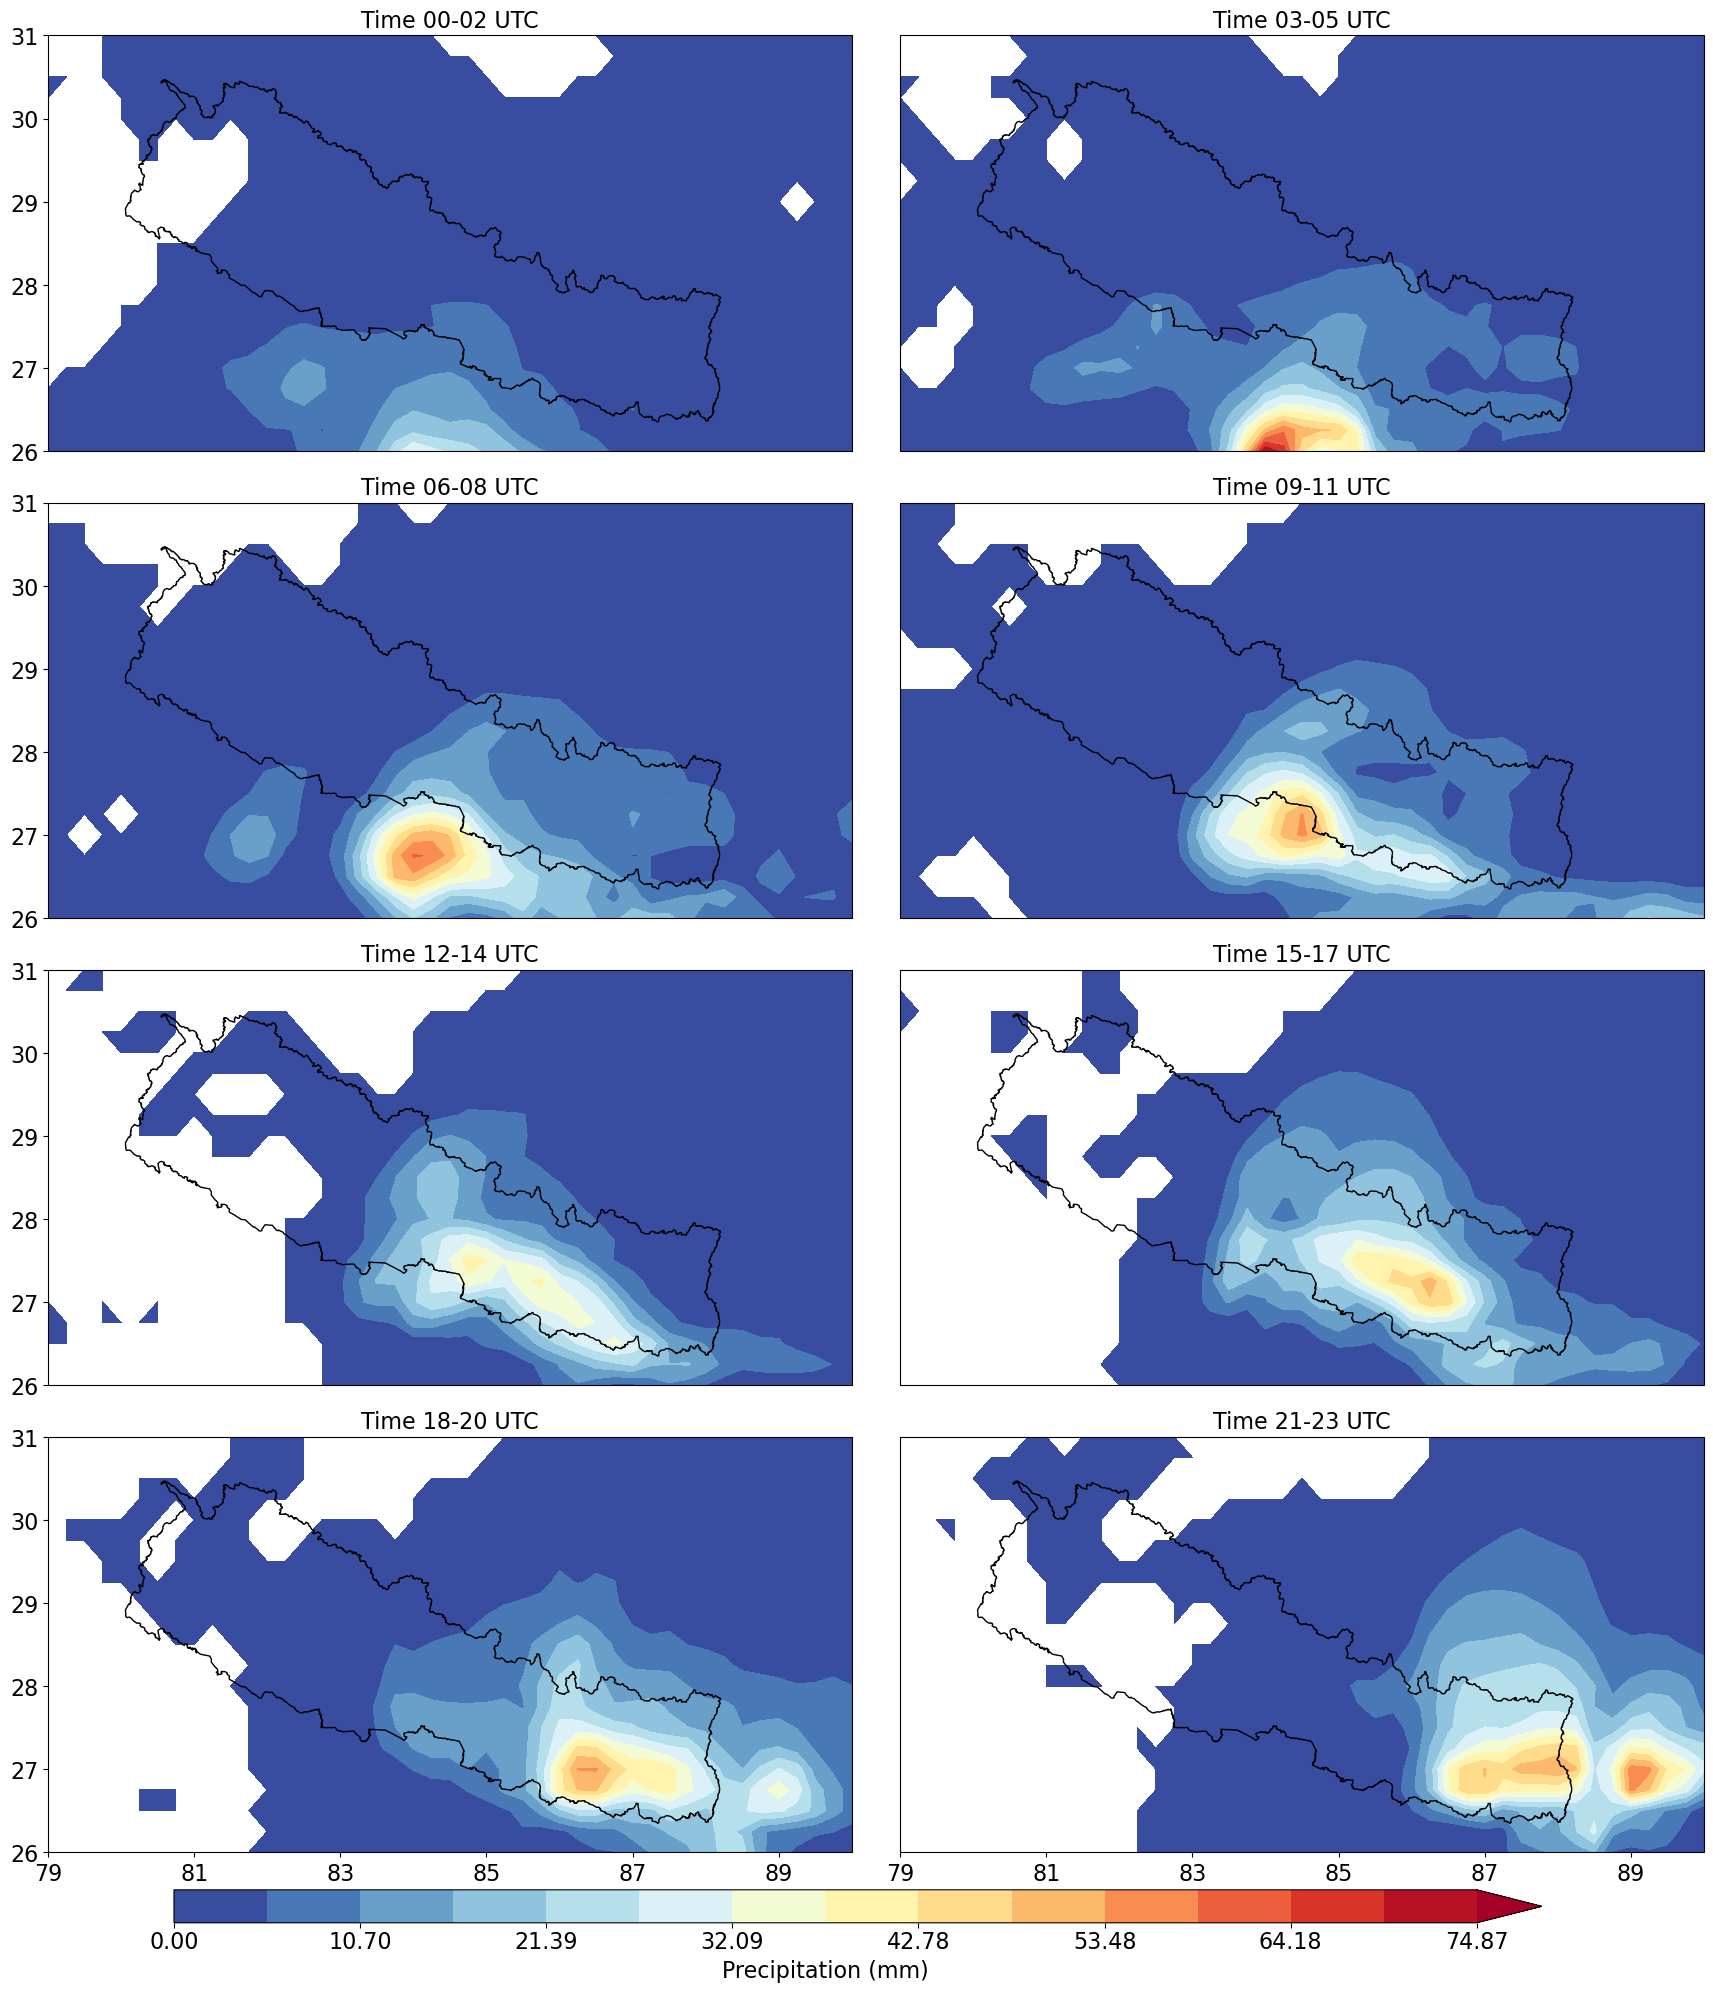

In [51]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import pandas as pd

# -------------------------------------------------
# ERA5 NetCDF file
# -------------------------------------------------
nc_file = '/Users/beekenshrestha/Downloads/RESEARCH/5yrs_oct4-6/ERA5/tp.nc'

# -------------------------------------------------
# Load shapefile
# -------------------------------------------------
shp_path = '/Users/beekenshrestha/Downloads/NPL/Nepal_shp/hermes_NPL_new_wgs_0.shp'
shp = gpd.read_file(shp_path)

# -------------------------------------------------
# Load the dataset
# -------------------------------------------------
ds = xr.open_dataset(nc_file, engine='netcdf4')  # specify engine
tp = ds['tp'] * 1000  # convert m → mm
time_dim = 'valid_time'  # adjust if needed

# -------------------------------------------------
# Select a specific date: 10-04
# -------------------------------------------------
tp = tp.sel({time_dim: pd.to_datetime(tp[time_dim].values)})
tp_day = tp.sel({time_dim: tp[time_dim].dt.strftime('%m-%d') == '10-04'})

# -------------------------------------------------
# Define 3-hourly intervals to sum
# -------------------------------------------------
# ERA5 is typically 3-hourly, so group as: 00-02, 03-05, ..., 21-23
intervals = [(i, i+2) for i in range(0, 24, 3)]  # [(0,2),(3,5),...,(21,23)]

tp_summed_list = []
for start_hour, end_hour in intervals:
    da_interval = tp_day.sel({time_dim: (tp_day[time_dim].dt.hour >= start_hour) & 
                                         (tp_day[time_dim].dt.hour <= end_hour)})
    if len(da_interval) > 0:
        tp_summed_list.append(da_interval.sum(dim=time_dim))

# Determine global min/max for consistent color scale
all_min = min([float(da.min()) for da in tp_summed_list])
all_max = max([float(da.max()) for da in tp_summed_list])
levels = np.linspace(all_min, all_max, 15)
cmap = plt.cm.RdYlBu_r

# -------------------------------------------------
# Prepare 4x2 panel
# -------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(18, 22), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# -------------------------------------------------
# Plot each summed interval
# -------------------------------------------------
for i, da2d in enumerate(tp_summed_list):
    ax = axes[i]

    # Handle latitude order
    if da2d.latitude[0] > da2d.latitude[-1]:
        da2d = da2d.sel(latitude=slice(31, 26), longitude=slice(79, 90))
    else:
        da2d = da2d.sel(latitude=slice(26, 31), longitude=slice(79, 90))

    lat = da2d['latitude'].values
    lon = da2d['longitude'].values
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Mask zero values
    da_masked = np.ma.masked_equal(da2d, 0)

    # Filled contour
    cf = ax.contourf(lon2d, lat2d, da_masked, levels=levels, cmap=cmap, extend='max')

    # Overlay shapefile
    shp.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

    # Set extent
    ax.set_extent([79, 90, 26, 31], crs=ccrs.PlateCarree())

    # Latitude ticks for first column
    if i % 2 == 0:
        ax.set_yticks(np.arange(26, 32, 1))
        ax.tick_params(axis='y', labelsize=16)
    else:
        ax.set_yticks([])

    # Longitude ticks for last row
    if i >= 6:
        ax.set_xticks(np.arange(79, 91, 2))
        ax.tick_params(axis='x', labelsize=16)
    else:
        ax.set_xticks([])

    # Title for each interval
    start_hour, end_hour = intervals[i]
    ax.set_title(f'Time {start_hour:02d}-{end_hour:02d} UTC', fontsize=16)

# Hide unused subplots if any
for j in range(len(tp_summed_list), 8):
    axes[j].axis('off')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.12, 0.09, 0.76, 0.015])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal', label='Precipitation (mm)')
cbar.ax.tick_params(labelsize=16, pad=2)
cbar.set_label('Precipitation (mm)', fontsize=16)

# Adjust spacing
plt.subplots_adjust(left=0.05, right=0.97, top=0.95, bottom=0.12, wspace=0.06, hspace=0.1)
plt.show()
